# 28_01 — Datos reales y preprocesamiento · Santiago, Parque O'Higgins · PM2.5 horario (SINCA)

Paso **1 de 5** del ciclo `Python → MATLAB → Python`:
- 01: **este notebook** lee el PM2.5 horario, arma la curva diaria, ajusta base B-spline (GCV) + FPCA (**sin estandarizar los scores**) y escribe los datasets AR
- 02: `psbp_fd_iteracion.m` muestreo MCMC en MATLAB, sólo con el bloque de entrenamiento
- 03, 04, 05: `28_03_convergencia` / `28_04_evaluacion` / `28_05_comparacion`

Las celdas **`[CONFIG]`** son las únicas que se tocan al cambiar de corrida.

> **Diseño de la corrida 28**: el pipeline de la 27 sobre otra serie real; sólo cambia la fuente y la curva (§2).
> - sampler y hiperparámetros de la variante **`chungEscG`** (`taupsij = 10·sd_x²`, `N = 30`, 3 cadenas);
> - covariables: **cruzadas con un solo rezago** ($p=M$, `N_LAGS = 1`); MATLAB entrena **cada** $M$;
> - no se descarta ningún día ni se imputan horas: la base se ajusta directo sobre las horas observadas (§3.2) y los días sin dato toman coeficientes interpolados en el tiempo;
> - representación estimada (B-spline por GCV, §3.1–3.2) y FPCA sobre los coeficientes (§3.3), sólo con train;
> - objetivo de evaluación: **curva suavizada** (docs §03_05_00).
>
> La curva es el **PM2.5 horario** (µg/m³) de la estación Parque O'Higgins (código D14 de la red MACAM, SINCA, Ministerio del Medio Ambiente), 24 valores por día. La concentración es positiva y asimétrica, con episodios de invierno (mayo–agosto) por mala ventilación de la cuenca; la curva principal es $X_t(\tau_m)=\log(1+\mathrm{PM2.5}_{t,m})$. Las cifras **no** son comparables con las de 21-27.

## 1. Imports y rutas

In [48]:
import json
import math
import sys
from datetime import datetime

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# Contrato de artefactos: mismos escritores que en simulación
from model_psbp_fd.pipelines import (
    guardar_curvas, guardar_representacion, guardar_fpca,
    guardar_estandarizador, guardar_datasets_ar,
    guardar_hiperparametros, guardar_config_evaluacion,
    verificar_contrato,
)
# Preprocesamiento funcional
from model_psbp_fd.functions_models import (
    FunctionalRepresentation, FPCA_L2, base_en_grilla, DataStandardizer,
)
from model_psbp_fd.fit import tabla_baselines, mise
# Rutas del contrato: el gemelo Python de config_paths.m.
from model_psbp_fd.utils import (
    get_project_root, normalizar_lista_M, construir_paths,
    guardar_en_todos, replicar_figura, pesos_trapezoidales,
)
from model_psbp_fd.graphics import (
    plot_empirical_sample, plot_mean_and_variance, plot_fts_empirical,
    plot_fts_functional, plot_diagnostico_estandarizacion, plot_fpca_scree,
    plot_seleccion_basis, plot_rezagos_heatmap, plot_series_componentes,
)

plt.style.use("seaborn-v0_8-darkgrid")
%matplotlib inline

### 1.1 `[CONFIG]` Identificación del experimento y barrido en $M$

In [49]:
PROJECT_ROOT = get_project_root()
if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))

# [CONFIG] debe coincidir con 28_03, 28_04, 28_05 y con psbp_fd_iteracion.m
BASENAME     = "real"
SERIE_ID     = "pm25_poh"    # PM2.5, Parque O'Higgins

# Curva diaria (§2.1). Cada curva tiene su VENTANA_ID: no se pisan artefactos.
CURVA        = "pm25_log"      # o "pm25" (cambiar SERIE_ID para no pisar artefactos)

# Ventana temporal: rango de fechas y corte train/test. Cada una escribe en su propia VENTANA_ID.
VENTANAS = {
    1: {"inicio": "2015-01-01", "fin": "2025-12-31", "prop_train": 0.70},           # 70/30 sobre todo el rango
    2: {"inicio": "2015-01-01", "fin": "2025-12-31", "train_hasta": "2022-12-31"},  # entrena 2015-2022, prueba 2023-2025
}
VENTANA_ID   = 2                      # 28_03/04/05 y el .m declaran este mismo valor
VENTANA      = VENTANAS[VENTANA_ID]
SEED         = 41232      # semilla base; MATLAB la LEE de hyperparameters.json

# [BARRIDO] componentes FPCA retenidas; igual en los cuatro notebooks.
M_FPCA_LIST = (1, 2, 3, 4, 5, 6)

# Covariables CRUZADAS con un solo rezago: xi_(k,t) se predice con xi_(1..M, t-1), p = M.
# El diseno cambia con M, asi que MATLAB entrena CADA M (no hay reutilizacion de trazas).
CRUZADOS = True

LIMPIAR_DIRECTORIOS = True

# Hiperparámetros de la 200, variante chungEscG: Chung §4.2 en escala cruda con gating
# más libre (taupsij_z = 10, sd a priori de psi 0.32 en unidades z).
VAR_CFG = {"hiperparametros": "chung_escala_cruda", "N": 30, "taupsij_z": 10.0}

M_FPCA_LIST     = normalizar_lista_M(M_FPCA_LIST)
M_ENTRENO       = max(M_FPCA_LIST)   # rezago propio: único M que se entrena (cruzados: todos)
EXPERIMENT_BASE = f"{BASENAME}_{SERIE_ID}_v{VENTANA_ID:02d}"


def eid_de(M: int) -> str:
    """real_<serie>_v<ventana a 2 digitos>_m<M a 2 digitos>"""
    return f"{EXPERIMENT_BASE}_m{int(M):02d}"


print(f"PROJECT_ROOT    : {PROJECT_ROOT}")
print(f"EXPERIMENT_BASE : {EXPERIMENT_BASE}")
print(f"serie {SERIE_ID} · curva {CURVA} -> ventana {VENTANA_ID} · seed base {SEED}")
print(f"barrido en M    : {list(M_FPCA_LIST)}   (cruzados: se entrena CADA M)")
for _M in M_FPCA_LIST:
    print(f"   M={_M}  ->  {eid_de(_M)}")

PROJECT_ROOT    : C:\Users\56jua\Desktop\git_tesis\bayesian_non_parametrics-1
EXPERIMENT_BASE : real_pm25_poh_v02
serie pm25_poh · curva pm25_log -> ventana 2 · seed base 41232
barrido en M    : [1, 2, 3, 4, 5, 6]   (cruzados: se entrena CADA M)
   M=1  ->  real_pm25_poh_v02_m01
   M=2  ->  real_pm25_poh_v02_m02
   M=3  ->  real_pm25_poh_v02_m03
   M=4  ->  real_pm25_poh_v02_m04
   M=5  ->  real_pm25_poh_v02_m05
   M=6  ->  real_pm25_poh_v02_m06


In [50]:
PATHS_POR_M = {M: construir_paths(eid_de(M), dominio="reales",
                                  project_root=PROJECT_ROOT,
                                  limpiar=LIMPIAR_DIRECTORIOS)
               for M in M_FPCA_LIST}

for M, p in PATHS_POR_M.items():
    print(f"M={M}  ({eid_de(M)})")
    for nombre, ruta in p.items():
        print(f"  {nombre:12s} -> {ruta}")

M=1  (real_pm25_poh_v02_m01)
  raw          -> C:\Users\56jua\Desktop\git_tesis\bayesian_non_parametrics-1\data\reales\raw\real_pm25_poh_v02_m01
  functional   -> C:\Users\56jua\Desktop\git_tesis\bayesian_non_parametrics-1\data\reales\processed\functional\real_pm25_poh_v02_m01
  predict      -> C:\Users\56jua\Desktop\git_tesis\bayesian_non_parametrics-1\data\reales\processed\predict\real_pm25_poh_v02_m01
  out_report   -> C:\Users\56jua\Desktop\git_tesis\bayesian_non_parametrics-1\reports\reales\real_pm25_poh_v02_m01
  out_artefact -> C:\Users\56jua\Desktop\git_tesis\bayesian_non_parametrics-1\artefact\reales\real_pm25_poh_v02_m01
M=2  (real_pm25_poh_v02_m02)
  raw          -> C:\Users\56jua\Desktop\git_tesis\bayesian_non_parametrics-1\data\reales\raw\real_pm25_poh_v02_m02
  functional   -> C:\Users\56jua\Desktop\git_tesis\bayesian_non_parametrics-1\data\reales\processed\functional\real_pm25_poh_v02_m02
  predict      -> C:\Users\56jua\Desktop\git_tesis\bayesian_non_parametrics-1\data\

## 2. Datos

### 2.1 `[CONFIG]` Fuente, curva y rango de fechas

PM2.5 horario de la estación **Parque O'Higgins** (D14), descargado de SINCA (`apub.tsindico2.cgi`, macro `./RM/D14/Cal/PM25//PM25.horario.horario.ic`). Cada fila trae `FECHA (YYMMDD)`, `HORA (HHMM)` y el valor en una de tres columnas: **validado**, preliminar o no validado. Sólo se usan los **validados**. La hora `HHMM` marca el fin de cada hora (§2.2); cada día tiene 24 horas, de 00:00–01:00 a 23:00–24:00, y la grilla es $	au_m=(m-1)/23$, $m=1,\dots,24$. `CURVA` se declara en §1.1.

| `CURVA` | $X_t(\tau_m)$, $m=1,\dots,24$ | uso |
|---|---|---|
| `"pm25_log"` | $\log(1+\mathrm{PM2.5}_{t,m})$ | **principal** |
| `"pm25"` | $\mathrm{PM2.5}_{t,m}$ en µg/m³ | variante en nivel (dominada por los episodios) |

`FECHA_INICIO` / `FECHA_FIN` (inclusivas) fijan el rango; **No se descarta ningún día**: $T$ es el número de días calendario del rango.

In [51]:
DIR_SINCA = PROJECT_ROOT / "data" / "reales" / "raw" / "sinca_pm25"
ESTACION  = "Parque O'Higgins (D14)"
ARCHIVO   = DIR_SINCA / "PM25_horario_parque_ohiggins_D14.csv"

# -- Curva (CURVA se declara en §1.1) -----------------------------------------------
CURVAS = {"pm25_log": "log(1 + PM2.5)",
          "pm25":     "PM2.5 (ug/m3)"}
VARIABLE = CURVAS[CURVA]

# -- Rango de fechas ----------------------------------------------------------------
FECHA_INICIO = VENTANA["inicio"]
FECHA_FIN    = VENTANA["fin"]    # inclusiva; None = ultimo dia disponible
PROP_TRAIN   = VENTANA.get("prop_train")   # T0 = floor(PROP_TRAIN * T); None si el corte es por fecha (train_hasta)

# -- Esquema de observacion ------------------------------------------------------
BARRAS_DIA    = 24               # G: una hora por barra
MAX_AUSENTES_AJUSTE = 12         # horas: con mas ausentes el dia toma coeficientes interpolados en el tiempo
                                 # (calibrado con huecos artificiales: desde ~12 h el dia vecino predice igual o mejor)

assert CURVA in CURVAS, f"CURVA admitida: {list(CURVAS)}"
assert ARCHIVO.exists(), f"No esta {ARCHIVO}"
print(f"archivo  : {ARCHIVO.name}  ·  estacion {ESTACION}")
print(f"curva    : {CURVA}  ({VARIABLE})")
print(f"rango    : {FECHA_INICIO}  ...  {FECHA_FIN or 'fin de los datos'}   ·   paso 1 h")

archivo  : PM25_horario_parque_ohiggins_D14.csv  ·  estacion Parque O'Higgins (D14)
curva    : pm25_log  (log(1 + PM2.5))
rango    : 2015-01-01  ...  2025-12-31   ·   paso 1 h


### 2.2 Lectura, control de calidad y huecos

`HORA` marca el **fin** de la hora promediada: `0100` es 00:00–01:00 y `0000` de la fecha $D$ es 23:00–24:00 del día $D-1$. El día y la barra se asignan por el inicio del intervalo, así la barra 0 es 00:00–01:00 y la 23 es 23:00–24:00. Se exige una fila por (día, barra) sin duplicados. Los valores preliminares y no validados quedan como ausentes.

**No se descarta ningún día ni se imputa ninguna hora aquí**: `X_raw` conserva los `NaN`. Las ausencias responden a la operación de la estación (mantención, fallas, control de calidad; se concentran en marzo–abril), no al nivel de PM2.5. Cómo entran a la representación se fija en §3.2.

In [52]:
kl = pd.read_csv(ARCHIVO, sep=";", dtype=str)
kl.columns = ["fecha", "hora", "validado", "preliminar", "no_validado"] + list(kl.columns[5:])
# HHMM marca el FIN de la hora promediada (convencion Airviro): 0100 es 00:00-01:00 y
# 0000 de la fecha D es 23:00-24:00 de D-1. El dia lo define el inicio del intervalo.
_hora = kl["hora"].str[:2].astype(int)
assert _hora.between(0, 23).all(), "HORA fuera de 00..23."
kl["t_ini"] = pd.to_datetime(kl["fecha"], format="%y%m%d") + pd.to_timedelta(_hora - 1, unit="h")
kl["dia"]   = kl["t_ini"].dt.floor("D")
kl["barra"] = kl["t_ini"].dt.hour             # 0 = 00:00-01:00 ... 23 = 23:00-24:00
kl["pm25"]  = pd.to_numeric(kl["validado"], errors="coerce")
_dup = int(kl.duplicated(["dia", "barra"]).sum())
assert _dup == 0, f"{_dup} (dia, hora) duplicados."
print(f"filas leidas : {len(kl)}   ·   cobertura {kl['dia'].min().date()} ... {kl['dia'].max().date()}")
print("registros por tipo:", {c: int(pd.to_numeric(kl[c], errors='coerce').notna().sum())
                              for c in ("validado", "preliminar", "no_validado")})

_pm = kl["pm25"].dropna().to_numpy()
print(f"PM2.5 validado: min {_pm.min():.0f}  mediana {np.median(_pm):.0f}  max {_pm.max():.0f} ug/m3   "
      f"·   > 50 (norma diaria): {(_pm > 50).mean():.2%}")
assert (_pm >= 0).all(), "PM2.5 negativo."

# -- Rango pedido y matriz (dia x hora): todos los dias calendario, con NaN ---------
_ini = pd.Timestamp(FECHA_INICIO)
_fin = pd.Timestamp(FECHA_FIN) if FECHA_FIN is not None else kl["dia"].max()
_dias_cal = pd.date_range(_ini, _fin, freq="D")
PM_M = (kl.pivot(index="dia", columns="barra", values="pm25")
          .reindex(index=_dias_cal, columns=range(BARRAS_DIA)))
AUSENTE = PM_M.isna().to_numpy()               # (T, G) horas sin dato validado

_na_dia = AUSENTE.sum(axis=1)
DIA_COMPLETO = _na_dia == 0
DIA_VACIO    = _na_dia == BARRAS_DIA
DIA_INTERPOLADO = _na_dia > MAX_AUSENTES_AJUSTE  # incluye los vacios
HUECOS = {
    "horas_ausentes":      int(AUSENTE.sum()),
    "frac_horas_ausentes": round(float(AUSENTE.mean()), 6),
    "dias_completos":      int(DIA_COMPLETO.sum()),
    "dias_con_huecos":     int((~DIA_COMPLETO & ~DIA_VACIO).sum()),
    "dias_sin_dato":       int(DIA_VACIO.sum()),
    "dias_interpolados":   int((_na_dia > MAX_AUSENTES_AJUSTE).sum()),     # sin dato o con > MAX_AUSENTES_AJUSTE h ausentes
    "dias_sin_dato_lista": [str(d.date()) for d in _dias_cal[DIA_VACIO]],
}
print(f"\ndias calendario: {len(_dias_cal)}   (ninguno se descarta)")
for k, v in HUECOS.items():
    if k != "dias_sin_dato_lista":
        print(f"  {k:20s} = {v}")
display(pd.Series(_na_dia, index=_dias_cal).groupby(_dias_cal.year)
        .agg(horas_ausentes="sum", dias_sin_dato=lambda s: int((s == BARRAS_DIA).sum())).T)

filas leidas : 234623   ·   cobertura 2000-01-01 ... 2026-10-06
registros por tipo: {'validado': 212859, 'preliminar': 1095, 'no_validado': 1411}
PM2.5 validado: min 0  mediana 22  max 327 ug/m3   ·   > 50 (norma diaria): 13.80%

dias calendario: 4018   (ninguno se descarta)
  horas_ausentes       = 2628
  frac_horas_ausentes  = 0.027252
  dias_completos       = 3737
  dias_con_huecos      = 221
  dias_sin_dato        = 60
  dias_interpolados    = 99


,2015,2016,2017,2018,2019,2020,2021,2022,2023,2024,2025
horas_ausentes,168,262,280,342,168,292,217,112,224,349,214
dias_sin_dato,2,7,7,8,4,9,4,2,5,6,6


In [53]:
# -- Curva segun CURVA -------------------------------------------------------------
_pm_m = PM_M.to_numpy(dtype=float)
X_raw = np.log1p(_pm_m) if CURVA == "pm25_log" else _pm_m     # con NaN en las horas ausentes
VOL_DIA = np.nansum(np.diff(X_raw, axis=1) ** 2, axis=1)  # variacion cuadratica diaria (diagnostico; 0 si no hay dato)
VOL_DIA[DIA_VACIO] = np.nan

# -- Continuidad temporal: un dia ausente hace que el rezago l no sea t-l ------------
_idx    = pd.Series(PM_M.index)
_saltos = int((_idx.diff().dt.days.dropna() != 1).sum())
assert _saltos == 0, "La serie diaria debe ser continua (no se descartan dias)."

T, G   = X_raw.shape
assert G == BARRAS_DIA
grilla = np.linspace(0.0, 1.0, G)             # tau_1 = 0 ... tau_G = 1
DIAS   = PM_M.index.to_numpy()
MES    = pd.DatetimeIndex(DIAS).month.to_numpy()
INVIERNO = np.isin(MES, [5, 6, 7, 8])         # diagnostico: no entra al modelo

# -- Corte train/test: lo fija la ventana, por fecha (train_hasta) o por proporcion ----------
if VENTANA.get("train_hasta") is None:
    T0 = int(np.floor(PROP_TRAIN * T))
else:
    T0 = int((pd.DatetimeIndex(DIAS) <= pd.Timestamp(VENTANA["train_hasta"])).sum())
    PROP_TRAIN = T0 / T

print(f"curvas   : X_raw {X_raw.shape}   (T={T} dias, G={G} horas por dia)")
print(f"periodo  : {pd.Timestamp(DIAS[0]).date()}  ...  {pd.Timestamp(DIAS[-1]).date()}")
print(f"particion: T0 = {T0}, test = {T - T0}   (PROP_TRAIN = {PROP_TRAIN:.4f})")
print(f"rango de {VARIABLE}: [{np.nanmin(X_raw):.4f}, {np.nanmax(X_raw):.4f}]  media {np.nanmean(X_raw):+.3f}")

# -- Diagnostico de la serie -------------------------------------------------------
def _acf1(x):
    return float(pd.Series(x).autocorr(1))      # omite los pares con NaN

_nivel = np.nanmean(np.where(DIA_VACIO[:, None], 0.0, X_raw), axis=1)
_nivel[DIA_VACIO] = np.nan                   # media diaria de la curva (horas observadas)
diagnostico = {
    "T": int(T), "G": int(G), "curva": CURVA,
    "acf1_nivel_diario":      round(_acf1(_nivel), 6),
    "acf1_variacion_cuad":    round(_acf1(VOL_DIA), 6),
    "sd_entre_dias":          round(float(np.nanstd(_nivel, ddof=1)), 6),
    "sd_intra_dia_media":     round(float(X_raw[DIA_COMPLETO].std(axis=1, ddof=1).mean()), 6),
    "razon_intra_entre":      round(float(X_raw[DIA_COMPLETO].std(axis=1, ddof=1).mean() / np.nanstd(_nivel, ddof=1)), 6),
    "asimetria_nivel":        round(float(pd.Series(_nivel).skew()), 6),
    "exceso_curtosis_nivel":  round(float(pd.Series(_nivel).kurt()), 6),
    "nivel_invierno_menos_resto": round(float(np.nanmean(_nivel[INVIERNO]) - np.nanmean(_nivel[~INVIERNO])), 6),
    "frac_pm25_mayor_50":     round(float(np.nanmean(_pm_m > 50)), 6),
    "pm25_max":               round(float(np.nanmax(_pm_m)), 2),
    "horas_ausentes":         HUECOS["horas_ausentes"],
    "dias_sin_dato":          HUECOS["dias_sin_dato"],
}
print("\nDiagnostico de la serie observada:")
for k, v in diagnostico.items():
    print(f"  {k:26s} = {v}")

curvas   : X_raw (4018, 24)   (T=4018 dias, G=24 horas por dia)
periodo  : 2015-01-01  ...  2025-12-31
particion: T0 = 2922, test = 1096   (PROP_TRAIN = 0.7272)
rango de log(1 + PM2.5): [0.0000, 5.5722]  media +2.993

Diagnostico de la serie observada:
  T                          = 4018
  G                          = 24
  curva                      = pm25_log
  acf1_nivel_diario          = 0.792399
  acf1_variacion_cuad        = 0.286191
  sd_entre_dias              = 0.5943
  sd_intra_dia_media         = 0.384425
  razon_intra_entre          = 0.646852
  asimetria_nivel            = 0.222057
  exceso_curtosis_nivel      = -0.507264
  nivel_invierno_menos_resto = 0.756489
  frac_pm25_mayor_50         = 0.102072
  pm25_max                   = 262.0
  horas_ausentes             = 2628
  dias_sin_dato              = 60


### 2.3 Visualización de la serie funcional

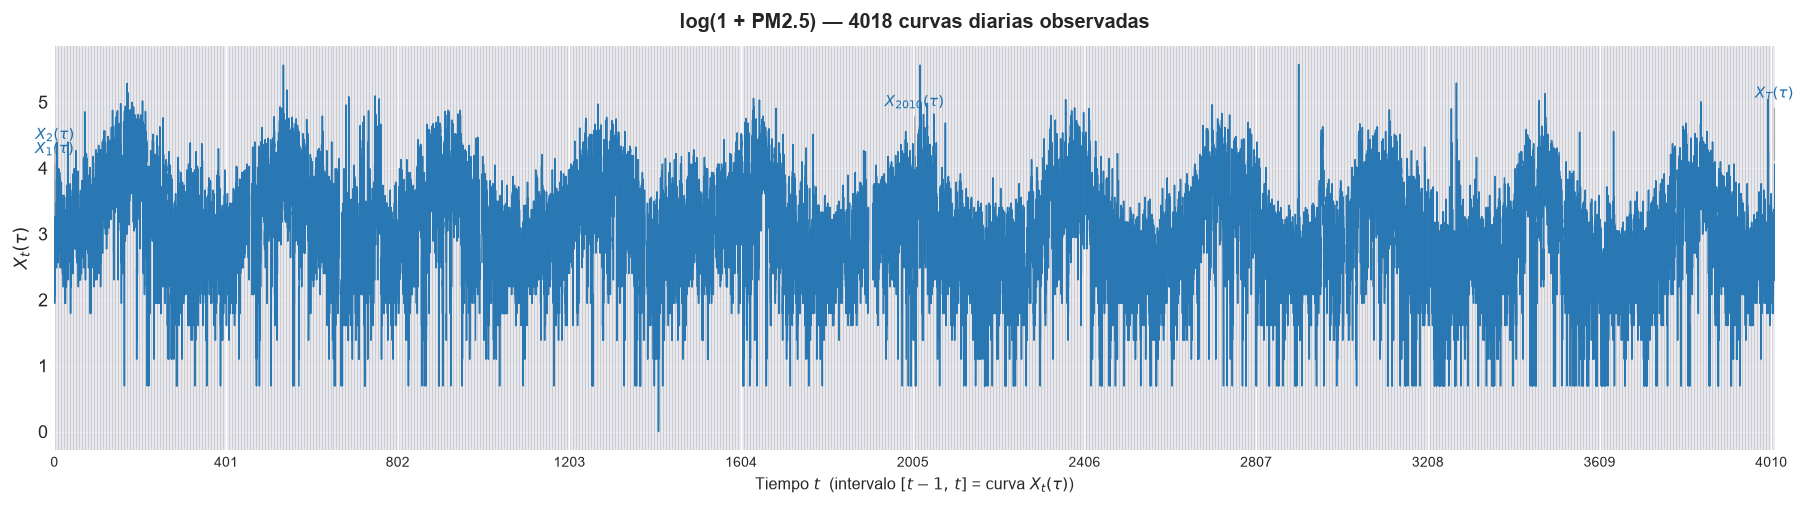

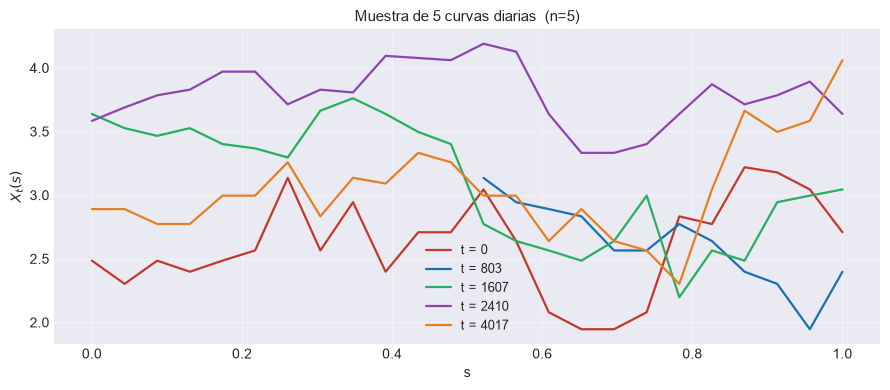

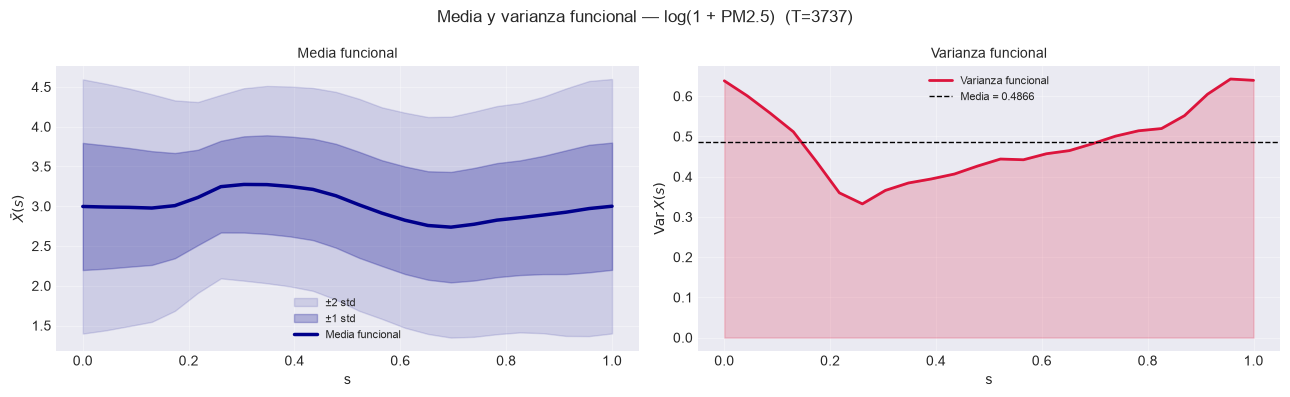

In [54]:
highlight_idx = [0, 1, T // 2, T - 1]

plot_fts_empirical(
    X_raw, grilla, highlight_idx=highlight_idx, separator_every=7,
    title=f"{VARIABLE} — {T} curvas diarias observadas")
replicar_figura("01_fts_empirica_raw.png", PATHS_POR_M)
plt.show()

plot_empirical_sample(
    X_raw, grilla, sample_idx=[0, T // 5, 2 * T // 5, 3 * T // 5, T - 1],
    title="Muestra de 5 curvas diarias")
replicar_figura("02_muestra_empirica_raw.png", PATHS_POR_M)
plt.show()

plot_mean_and_variance(
    X_raw[DIA_COMPLETO], grilla, show_std1=True, show_std2=True,
    title=f"Media y varianza funcional — {VARIABLE}")
replicar_figura("03_media_varianza_raw.png", PATHS_POR_M)
plt.show()

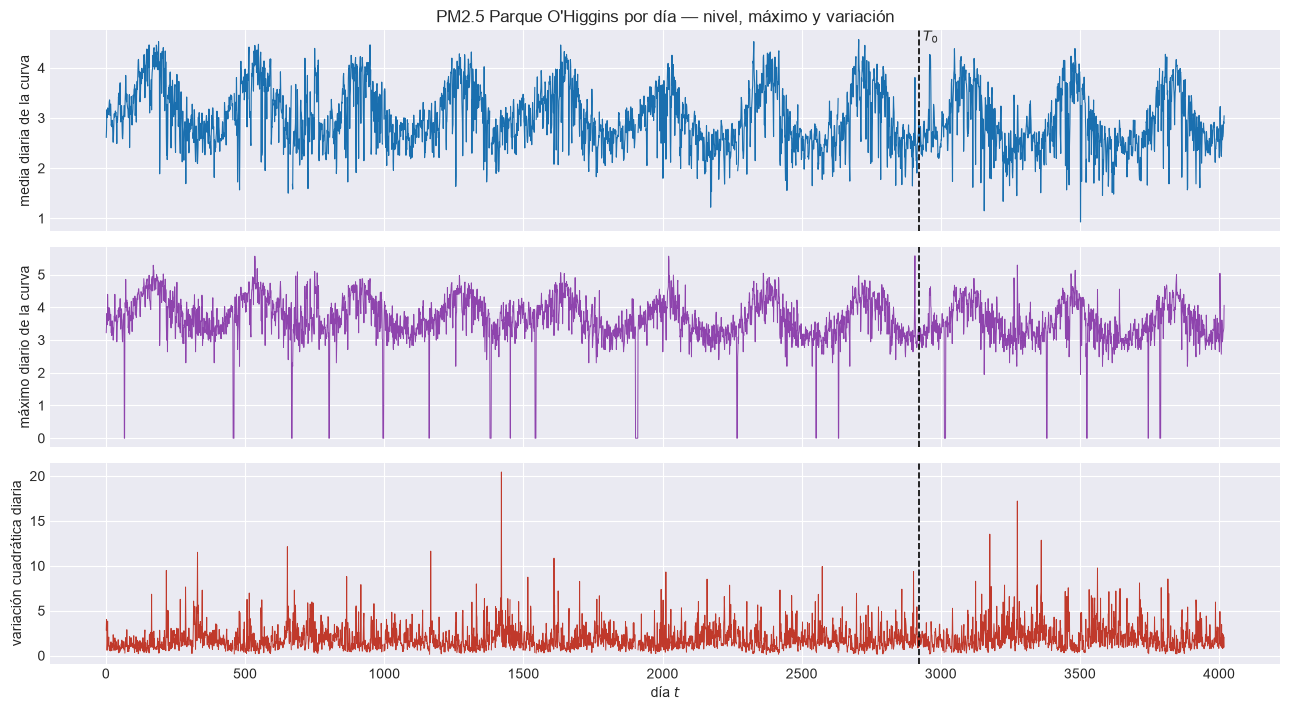

Por tercio de la muestra:  media de la curva · sd · variación cuadrática media
  tercio 1: +3.16669  (sd 0.58298)  ·  var.cuad. 1.751e+00
  tercio 2: +2.91771  (sd 0.53742)  ·  var.cuad. 1.902e+00
  tercio 3: +2.88868  (sd 0.61995)  ·  var.cuad. 2.031e+00
curva train [0.000, 5.572]  test [0.693, 5.288]


In [55]:
# Nivel de la curva y variacion cuadratica por dia con el corte train/test: los episodios
# de invierno viven en el nivel medio diario y en la amplitud del ciclo horario.
_T0_prev = T0

fig, axes = plt.subplots(3, 1, figsize=(13, 7.2), sharex=True)
axes[0].plot(np.arange(1, T + 1), _nivel, lw=0.8, color="#1a6faf")
axes[0].set_ylabel("media diaria de la curva")
axes[1].plot(np.arange(1, T + 1), np.nanmax(np.where(DIA_VACIO[:, None], 0.0, X_raw), axis=1), lw=0.7, color="#8e44ad")
axes[1].set_ylabel("máximo diario de la curva")
axes[2].plot(np.arange(1, T + 1), VOL_DIA, lw=0.7, color="#c0392b")
axes[2].set_ylabel("variación cuadrática diaria")
for ax in axes:
    ax.axvline(_T0_prev, color="k", ls="--", lw=1.2)
axes[0].text(_T0_prev, axes[0].get_ylim()[1], r" $T_0$", va="top", fontsize=10)
axes[2].set_xlabel("día $t$")
axes[0].set_title("PM2.5 Parque O'Higgins por día — nivel, máximo y variación")
fig.tight_layout()
replicar_figura("04_serie_diaria.png", PATHS_POR_M, fig=fig)
plt.show()

print("Por tercio de la muestra:  media de la curva · sd · variación cuadrática media")
for i, (_n3, _v3) in enumerate(zip(np.array_split(_nivel, 3), np.array_split(VOL_DIA, 3)), 1):
    print(f"  tercio {i}: {np.nanmean(_n3):+.5f}  (sd {np.nanstd(_n3, ddof=1):.5f})  ·  var.cuad. {np.nanmean(_v3):.3e}")
print(f"curva train [{np.nanmin(X_raw[:_T0_prev]):.3f}, {np.nanmax(X_raw[:_T0_prev]):.3f}]  "
      f"test [{np.nanmin(X_raw[_T0_prev:]):.3f}, {np.nanmax(X_raw[_T0_prev:]):.3f}]")

### 2.4 Persistencia de la fuente

Aquí sólo `dataset_config.json`, `dias.csv` y la máscara `ausente.csv`. `X_curves.npy` se persiste en §3.2: en las horas ausentes lleva el valor de la curva **suavizada** (la B-spline ajustada a las horas observadas), para que los consumidores de `X_obs` no reciban `NaN`. La máscara dice qué horas no son observadas.

In [56]:
# Análogo real de simulation_config.json. Documenta la fuente.
for _M, _p in PATHS_POR_M.items():
    dataset_config = {
        "fuente":        str(ARCHIVO),
        "origen":        "SINCA (sinca.mma.gob.cl), MMA Chile; macro ./RM/D14/Cal/PM25//PM25.horario.horario.ic",
        "estacion":      ESTACION,
        "registros":     "solo validados",
        "curva":         CURVA,
        "variable":      VARIABLE,
        "serie_id":      SERIE_ID,
        "ventana_id":    int(VENTANA_ID),
        "fecha_inicio_pedida": FECHA_INICIO,
        "fecha_fin_pedida":    FECHA_FIN,
        "fecha_inicio":  str(pd.Timestamp(DIAS[0]).date()),
        "fecha_fin":     str(pd.Timestamp(DIAS[-1]).date()),
        "T": int(T), "G": int(G),
        "prop_train":    float(PROP_TRAIN),
        "barras_dia":    int(BARRAS_DIA),
        "huecos":        {**HUECOS,
                          "representacion": "B-spline ajustada solo a las horas observadas (P-spline debil en dias con huecos)",
                          "max_ausentes_ajuste": int(MAX_AUSENTES_AJUSTE),
                          "penalizacion_huecos": "P-spline hacia la forma del perfil medio de train, lam = 10",
                          "dias_interpolados": "sin dato o > max_ausentes_ajuste horas ausentes: coeficientes interpolados linealmente en el tiempo",
                          "X_curves": "horas ausentes = curva suavizada"},
        "dias_descartados": [],
        "diagnostico":   diagnostico,
        "experiment_id": eid_de(_M),
        "m_fpca":        int(_M),
        "m_fpca_list":   [int(m) for m in M_FPCA_LIST],
        "seed":          SEED,
        "procesado":     datetime.now().strftime("%Y-%m-%d %H:%M:%S"),
    }
    with open(_p["raw"] / "dataset_config.json", "w", encoding="utf-8") as f:
        json.dump(dataset_config, f, indent=2, ensure_ascii=False)
    pd.Series(DIAS, name="dia").to_csv(_p["raw"] / "dias.csv", index=False)
    pd.DataFrame(AUSENTE.astype(int), index=pd.Index(DIAS, name="dia")).to_csv(_p["raw"] / "ausente.csv")
    print(f"[raw · M={_M}] dataset_config.json · dias.csv")

[raw · M=1] dataset_config.json · dias.csv
[raw · M=2] dataset_config.json · dias.csv
[raw · M=3] dataset_config.json · dias.csv
[raw · M=4] dataset_config.json · dias.csv
[raw · M=5] dataset_config.json · dias.csv
[raw · M=6] dataset_config.json · dias.csv


### 2.5 Partición temporal

Todo objeto **estimado a partir de los datos** —GCV de la base, FPCA,
estandarizador (en identidad)— se ajusta sólo con $\{1,\dots,T_0\}$ y se aplica
al bloque de prueba mediante `transform`.

In [57]:
# T0 ya se fijo en §2.2 (corte de la ventana)
assert 10 < T0 < T, f"T0={T0} fuera de rango para T={T}."

idx_train, idx_test = np.arange(0, T0), np.arange(T0, T)
X, X_train, X_test = X_raw, X_raw[idx_train], X_raw[idx_test]

print(f"entrenamiento : t ∈ [1, {T0}]      → {X_train.shape}   "
      f"(hasta {pd.Timestamp(DIAS[T0 - 1]).date()})")
print(f"prueba        : t ∈ [{T0+1}, {T}]  → {X_test.shape}")
print(f"proporción    : {T0/T:.1%} / {1 - T0/T:.1%}")

entrenamiento : t ∈ [1, 2922]      → (2922, 24)   (hasta 2022-12-31)
prueba        : t ∈ [2923, 4018]  → (1096, 24)
proporción    : 72.7% / 27.3%


## 3. Representación funcional B-spline

### 3.1 Barrido GCV sobre `(n_basis, order)`

El GCV **sugiere**; la elección es del analista y se declara en 3.2.

GCV sobre 2726 de 2922 dias de train (los completos)


,n_basis,order,var_retained,rmse_mean,rmse_max,gcv_mean
0,4,2,89.1133%,0.213594,0.663716,0.073381
1,5,2,90.1108%,0.202934,0.598117,0.073858
2,6,2,92.1848%,0.180017,0.566300,0.065034
3,7,2,93.6268%,0.162478,0.574844,0.059457
4,8,2,94.4484%,0.151265,0.539631,0.058469
5,9,2,95.1325%,0.141704,0.517729,0.058327
6,10,2,95.6786%,0.133052,0.526628,0.059445
7,11,2,96.1503%,0.125219,0.518655,0.061416
8,12,2,96.6570%,0.116577,0.495945,0.062593
9,13,2,97.1244%,0.108144,0.438917,0.064074



GCV mínimo → n_basis=9, order=2  (var retenida 95.1325%)


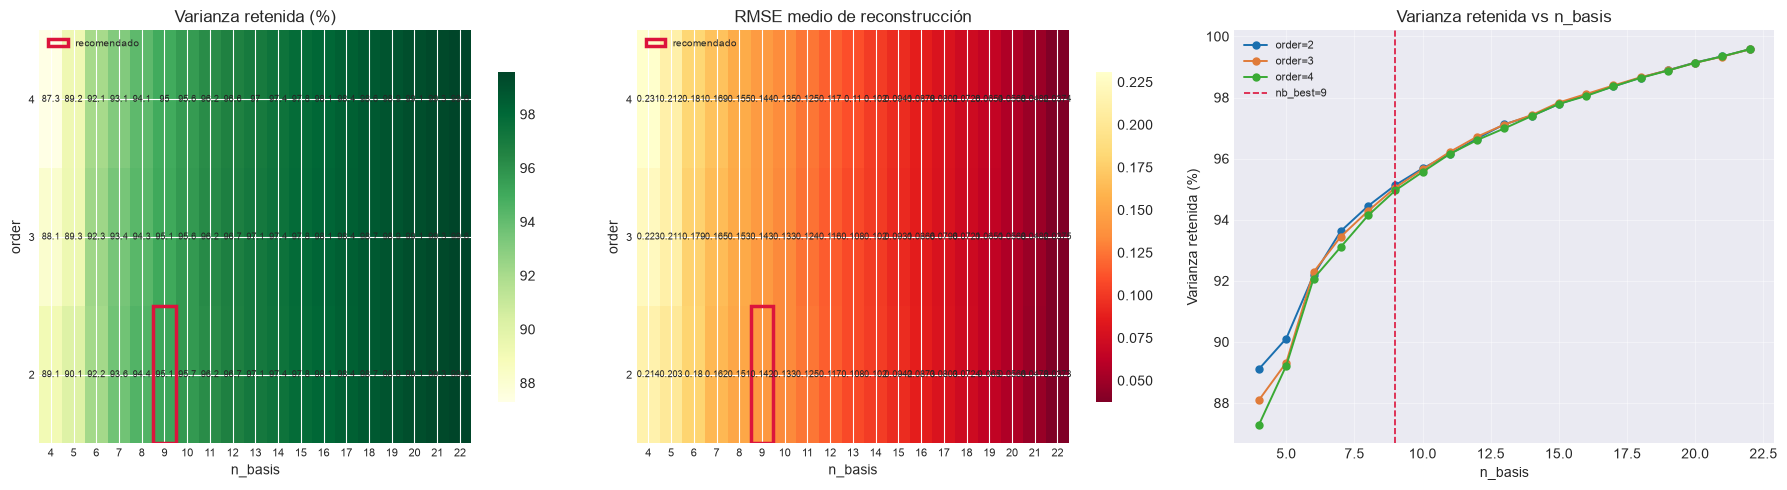

In [58]:
N_BASIS_RANGE = range(4, min(G - 1, T0 // 2))   # acotado por G = 24 (GCV exige n_basis < G)
ORDER_RANGE   = range(2, 5)

X_train_gcv = X_train[DIA_COMPLETO[idx_train]]     # el GCV necesita la curva completa
print(f"GCV sobre {len(X_train_gcv)} de {T0} dias de train (los completos)")
registros = []
for orden in ORDER_RANGE:
    for nb in N_BASIS_RANGE:
        if nb < orden:
            continue
        try:
            fr_tmp = FunctionalRepresentation(method="bspline", n_basis=nb, order=orden)
            TH_tmp = fr_tmp.fit_transform(X_train_gcv, grilla)     # sólo train, días completos
            X_rec  = fr_tmp.reconstruct(TH_tmp)

            L_i    = X_train_gcv.shape[1]
            sse_c  = np.sum((X_train_gcv - X_rec) ** 2, axis=1)
            ss_tot = np.sum((X_train_gcv - X_train_gcv.mean(axis=0, keepdims=True)) ** 2)
            gcv_c  = (L_i * sse_c / (L_i - nb) ** 2 if L_i > nb
                      else np.full_like(sse_c, np.nan))
            registros.append({
                "n_basis": nb, "order": orden,
                "var_retained": 1.0 - sse_c.sum() / ss_tot,
                "rmse_mean": np.sqrt(sse_c / L_i).mean(),
                "rmse_max":  np.sqrt(sse_c / L_i).max(),
                "gcv_mean":  float(np.mean(gcv_c)),
            })
        except Exception as e:
            print(f"  [SKIP] n_basis={nb}, order={orden}: {e}")

sel_df   = pd.DataFrame(registros)
best_row = sel_df.dropna(subset=["gcv_mean"]).nsmallest(1, "gcv_mean").iloc[0]
nb_best, ord_best = int(best_row["n_basis"]), int(best_row["order"])

display(sel_df.style
    .format({"var_retained": "{:.4%}", "rmse_mean": "{:.6f}",
             "rmse_max": "{:.6f}", "gcv_mean": "{:.6f}"})
    .background_gradient(subset=["gcv_mean"], cmap="YlOrRd_r")
    .background_gradient(subset=["var_retained"], cmap="YlGn"))

print(f"\nGCV mínimo → n_basis={nb_best}, order={ord_best}  "
      f"(var retenida {best_row['var_retained']:.4%})")
if nb_best == max(N_BASIS_RANGE):
    print(f"! el mínimo está en el borde del rango (n_basis={nb_best}): el GCV pediría "
          "más funciones. No se amplía el rango; §3.6 muestra el piso de la base.")

plot_seleccion_basis(sel_df, nb_best, ord_best)
replicar_figura("05_seleccion_basis.png", PATHS_POR_M)
plt.show()

### 3.2 `[CONFIG]` Base elegida y ajuste


Base elegida : n_basis=10, order=3
Sugerido GCV : n_basis=9, order=2   ← DIFIERE de la sugerencia; justificar en la tesis
THETA (4018, 10)  (train=2922, test=1096)   ·   dias interpolados: 99 (60 sin dato)
RMSE(suavizada, observada) en horas observadas = 0.1580
MISE(suavizada, observada) = 0.024645   (las horas ausentes aportan 0)
[functional] curvas       -> X_curves.npy   (replicado en 6 directorios)
[functional] grilla       -> domain_grid.npy   (replicado en 6 directorios)


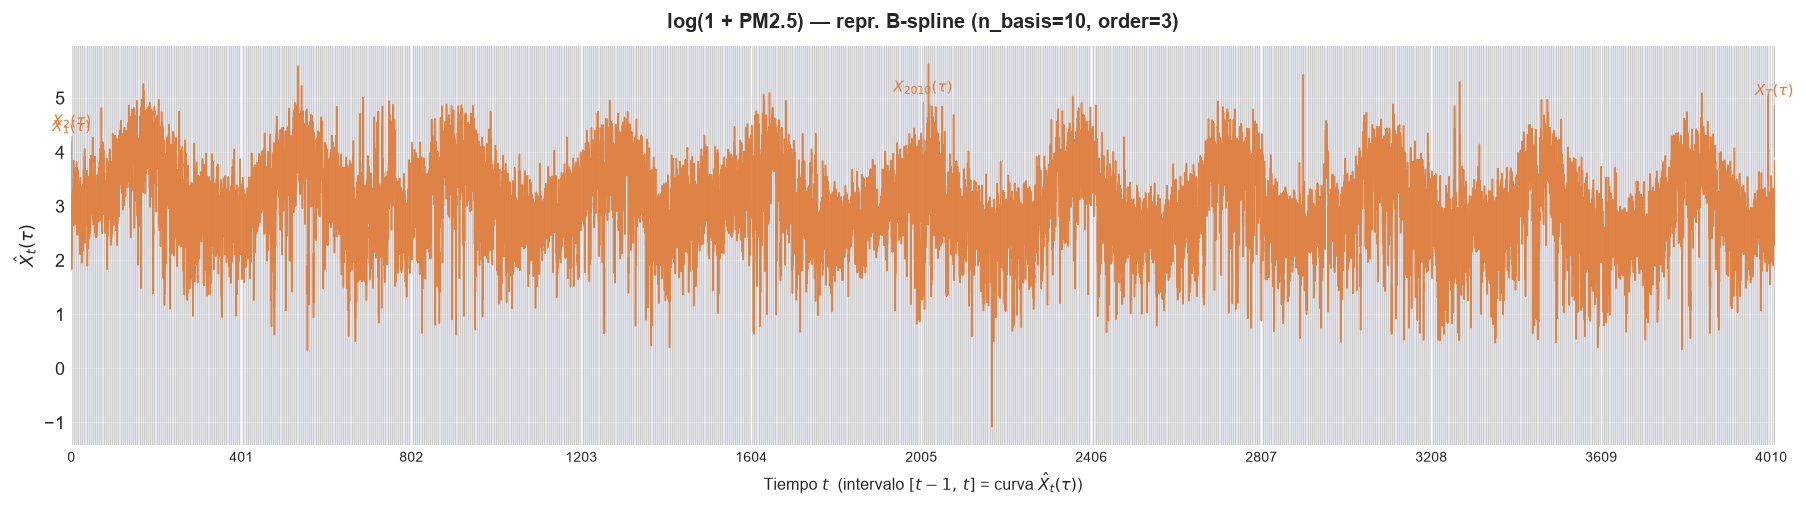

[functional] functional_representation.pkl + theta.csv + fr_config.json   (replicado en 6 directorios)


In [59]:
# ← decisión del analista. El GCV es plano (9/2: 0.0588 · 10/3: 0.0604) y sugiere orden 2,
# lineal a trozos (con quiebres). Se usa 10/3: curva suave, K = 10 para el barrido M = 1..10.
NB_ELEGIDO  = 10
ORD_ELEGIDO = 3

print(f"Base elegida : n_basis={NB_ELEGIDO}, order={ORD_ELEGIDO}")
print(f"Sugerido GCV : n_basis={nb_best}, order={ord_best}"
      + ("   (coinciden)" if (NB_ELEGIDO, ORD_ELEGIDO) == (nb_best, ord_best)
         else "   ← DIFIERE de la sugerencia; justificar en la tesis"))

fr = FunctionalRepresentation(method="bspline", n_basis=NB_ELEGIDO,
                              order=ORD_ELEGIDO, center=False)
fr.fit(X_train, grilla)                       # sólo train (la base no depende de los datos)
_X_fit = X.copy()
_X_fit[DIA_INTERPOLADO] = np.nan              # se interpolan en el tiempo, no se ajustan
THETA = fr.transform(_X_fit, grilla)          # (T, K): cada dia con sus horas observadas
assert np.isnan(THETA).any(axis=1).sum() == DIA_INTERPOLADO.sum()

# Dias sin dato o con > MAX_AUSENTES_AJUSTE h ausentes: coeficientes interpolados en el tiempo.
THETA = (pd.DataFrame(THETA, index=pd.DatetimeIndex(DIAS))
           .interpolate(method="time", limit_direction="both").to_numpy())
assert np.isfinite(THETA).all()
THETA_train = THETA[idx_train]
X_SUAV      = fr.reconstruct(THETA)           # objetivo de evaluacion (docs 03_05_00)

_obs = ~AUSENTE
print(f"THETA {THETA.shape}  (train={T0}, test={T - T0})   ·   dias interpolados: {int(DIA_INTERPOLADO.sum())} ({int(DIA_VACIO.sum())} sin dato)")
print(f"RMSE(suavizada, observada) en horas observadas = {np.sqrt(np.mean((X[_obs] - X_SUAV[_obs]) ** 2)):.4f}")

# Horas ausentes: la curva suavizada. X es X_raw (mismo objeto).
X[AUSENTE] = X_SUAV[AUSENTE]
assert np.isfinite(X_raw).all()
print(f"MISE(suavizada, observada) = {mise(X, X_SUAV, grilla):.6f}   (las horas ausentes aportan 0)")
_p = guardar_en_todos(guardar_curvas, PATHS_POR_M, X_raw, grilla)      # sin X_true: no existe
for clave, ruta in _p.items():
    print(f"[functional] {clave:12s} -> {ruta.name}   (replicado en {len(PATHS_POR_M)} directorios)")

plot_fts_functional(
    X, grilla, fr=fr, highlight_idx=highlight_idx, separator_every=5,
    title=f"{VARIABLE} — repr. B-spline (n_basis={NB_ELEGIDO}, order={ORD_ELEGIDO})")
replicar_figura("06_fts_funcional_bspline.png", PATHS_POR_M)
plt.show()

guardar_en_todos(guardar_representacion, PATHS_POR_M, fr, THETA,
    extra={"T0": int(T0), "prop_train": float(PROP_TRAIN), "ajustado_en": "train",
           "center": bool(fr.center), "n_basis": int(NB_ELEGIDO),
           "order": int(ORD_ELEGIDO), "n_basis_gcv": nb_best, "order_gcv": ord_best})
print(f"[functional] functional_representation.pkl + theta.csv + fr_config.json"
      f"   (replicado en {len(PATHS_POR_M)} directorios)")

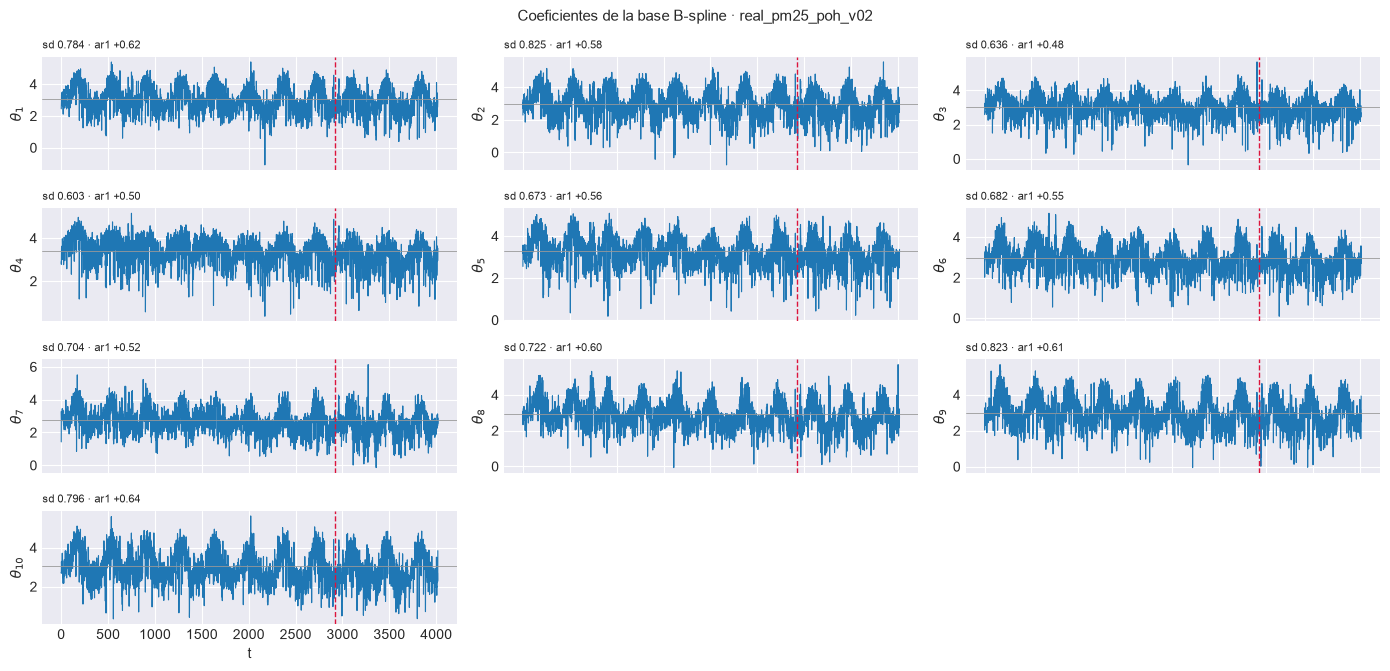

In [60]:
# Un panel por coeficiente theta_j de la base B-spline elegida (T, K).
fig = plot_series_componentes(
    THETA, T0=T0, simbolo=r"\theta", ncols=3,
    titulo=f"Coeficientes de la base B-spline · {EXPERIMENT_BASE}")
replicar_figura("06_series_coeficientes.png", PATHS_POR_M, fig=fig)
plt.show()

### 3.3 FPCA generalizado en $L^2$ y diagnóstico

In [61]:
Phi  = base_en_grilla(fr, THETA.shape[1])        # (G, K)
fpca = FPCA_L2().fit(THETA_train, Phi, grilla)

# tol 1e-8 y no 1e-10: con la base elegida y la curva en esta escala, var(xi)/lambda de las componentes
# de autovalor mínimo sale a ~1e-10 de error relativo, sólo redondeo.
TOL_FPCA = 1e-8
_ver = fpca.verificar(THETA_train, fr=fr, tol=TOL_FPCA)
print("Verificación FPCA_L2 (entrenamiento):")
for k, v in _ver.items():
    print(f"  {k:34s} = {v:.3e}" if isinstance(v, float) else f"  {k:34s} = {v}")

cond = _ver["cond_W"]
nota = ("← MUY ALTO: reduzca n_basis" if cond > 1e10 else
        "← alto: vigile las componentes menores" if cond > 1e6 else "(sano)")
print(f"\ncond(W) = {cond:.3e}  {nota}")

assert _ver["todo_ok"], ("Las identidades del FPCA generalizado no se cumplen. "
                         "Si falla err_linealidad_reconstruct_rel, revise center=False.")

Verificación FPCA_L2 (entrenamiento):
  M                                  = 10
  K                                  = 10
  n_ajuste                           = 2922
  cond_W                             = 8.435e+00
  err_ortonormalidad_L2              = 1.998e-15
  err_ortonormalidad_gram            = 1.998e-15
  var_explicada                      = 1.000e+00
  err_rutas_reconstruccion           = 8.882e-16
  err_linealidad_reconstruct         = 0.000e+00
  err_linealidad_reconstruct_rel     = 0.000e+00
  err_media_scores                   = 1.313e-15
  err_media_scores_rel               = 1.495e-14
  err_var_scores_vs_lambda           = 5.551e-16
  err_var_scores_vs_lambda_rel       = 4.186e-15
  err_correlacion_lag0               = 4.856e-15
  criterios_evaluados                = ['err_ortonormalidad_L2', 'err_ortonormalidad_gram', 'err_rutas_reconstruccion', 'err_correlacion_lag0', 'err_linealidad_reconstruct_rel', 'err_media_scores_rel', 'err_var_scores_vs_lambda_rel']
  todo_ok   

,componente,autovalor,var_ratio,var_acum,ar1_propio
0,1,3.3450e-01,76.6746%,76.6746%,+0.792
1,2,4.2269e-02,9.6890%,86.3636%,-0.049
2,3,2.4166e-02,5.5394%,91.9030%,+0.311
3,4,1.1700e-02,2.6819%,94.5849%,+0.094
4,5,7.7126e-03,1.7679%,96.3528%,+0.159
5,6,5.6772e-03,1.3013%,97.6541%,+0.080
6,7,3.9367e-03,0.9024%,98.5565%,+0.069
7,8,2.9601e-03,0.6785%,99.2350%,+0.094
8,9,1.8262e-03,0.4186%,99.6536%,+0.028
9,10,1.5112e-03,0.3464%,100.0000%,+0.044



K disponibles: 10   ·   sugerencia (var ≥ 95%): M = 5
  M=1: var. acum = 76.6746%  ·  sensibilidad
  M=2: var. acum = 86.3636%  ·  sensibilidad
  M=3: var. acum = 91.9030%  ·  sensibilidad
  M=4: var. acum = 94.5849%  ·  sensibilidad
  M=5: var. acum = 96.3528%  ·  regla del 95 %
  M=6: var. acum = 97.6541%  ·  sensibilidad


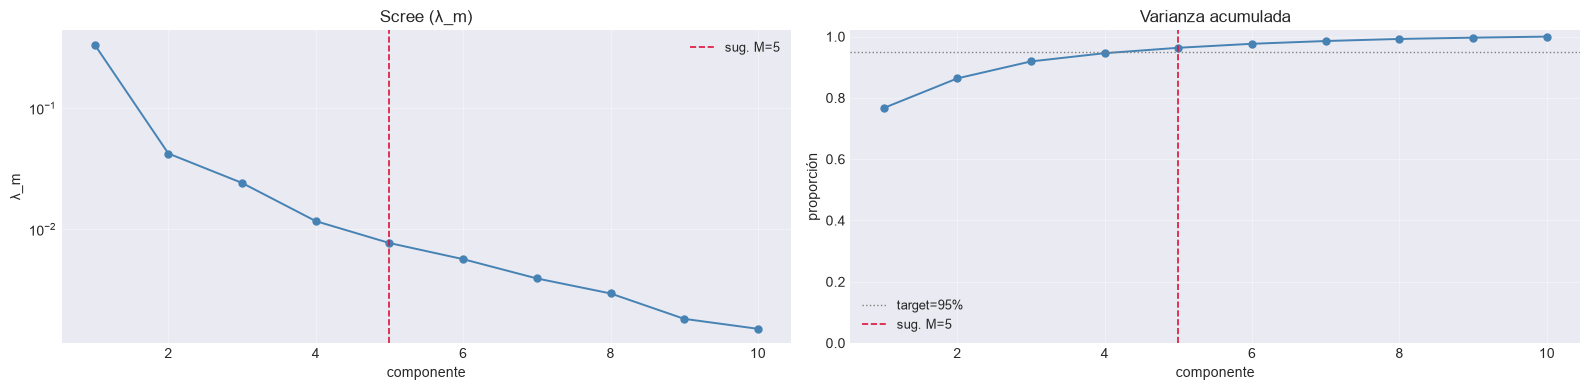

In [62]:
# Varianza != dinamica: una FPC de varianza baja puede tener AR fuerte.
K   = fpca.evals.size
S_a = (THETA_train - fpca.mu_theta) @ (fpca.W @ fpca.B_full)     # (T0, K)
ar1 = (S_a[1:] * S_a[:-1]).sum(0) / np.clip((S_a[:-1] ** 2).sum(0), 1e-12, None)

VAR_TARGET  = 0.95
M_SUGERIDO  = fpca.seleccionar_M(VAR_TARGET)

display(pd.DataFrame({
    "componente": np.arange(1, K + 1), "autovalor": fpca.evals,
    "var_ratio": fpca.var_ratio, "var_acum": fpca.var_cum, "ar1_propio": ar1,
}).head(min(15, K)).style.format(
    {"autovalor": "{:.4e}", "var_ratio": "{:.4%}",
     "var_acum": "{:.4%}", "ar1_propio": "{:+.3f}"})
    .background_gradient(subset=["var_ratio"], cmap="YlGn")
    .background_gradient(subset=["ar1_propio"], cmap="coolwarm", vmin=-1, vmax=1))

print(f"\nK disponibles: {K}   ·   sugerencia (var ≥ {VAR_TARGET:.0%}): M = {M_SUGERIDO}")

# K lo fija el GCV y ACOTA el barrido
assert max(M_FPCA_LIST) <= K, (
    f"M_FPCA_LIST={list(M_FPCA_LIST)} excede el K disponible: la base elegida "
    f"(n_basis={NB_ELEGIDO}, order={ORD_ELEGIDO}) da K = {K} componentes. "
    f"Reduzca el barrido o elija una base con más funciones en §3.2.")

_frontera = max(3, int(np.ceil(0.75 * K)))
for _M in M_FPCA_LIST:
    _marca = "regla del 95 %" if _M == M_SUGERIDO else "sensibilidad"
    _aviso = ("   <- cerca del techo K: componente en buena medida artefacto "
              "de una base corta" if _M >= _frontera else "")
    print(f"  M={_M}: var. acum = {fpca.var_cum[_M-1]:.4%}  ·  {_marca}{_aviso}")

plot_fpca_scree(fpca.evals, fpca.var_cum, M_SUGERIDO, var_target=VAR_TARGET)
replicar_figura("07_fpca_scree.png", PATHS_POR_M)
plt.show()

### 3.4 Series de los componentes de la FPCA

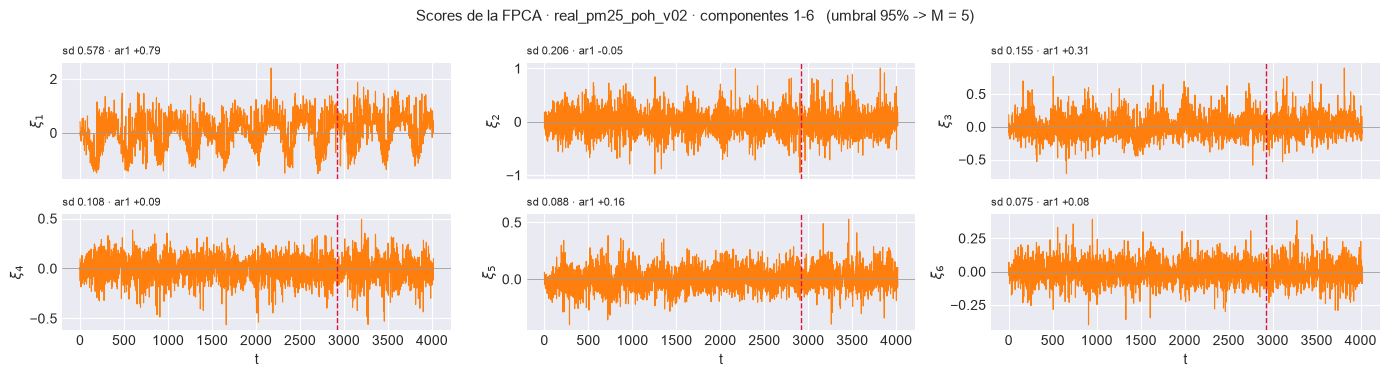

componentes graficadas : 1-6  de K = 10
var. acumulada hasta 6 : 97.6541%


In [63]:
# [CONFIG] hasta que componente se grafica: todas las del barrido.
N_SERIES_SCORES = max(M_FPCA_LIST)

assert 1 <= N_SERIES_SCORES <= K, f"N_SERIES_SCORES={N_SERIES_SCORES} fuera de [1, {K}]."

# B_full y no B: no depende de set_M. Serie completa, no solo train.
XI = (THETA - fpca.mu_theta) @ (fpca.W @ fpca.B_full)      # (T, K)

fig = plot_series_componentes(
    XI[:, :N_SERIES_SCORES], T0=T0, simbolo=r"\xi", color="C1", ncols=3,
    titulo=f"Scores de la FPCA · {EXPERIMENT_BASE} · componentes 1-{N_SERIES_SCORES}   "
           f"(umbral {VAR_TARGET:.0%} -> M = {M_SUGERIDO})")
replicar_figura("07b_series_scores.png", PATHS_POR_M, fig=fig)
plt.show()

print(f"componentes graficadas : 1-{N_SERIES_SCORES}  de K = {K}")
print(f"var. acumulada hasta {N_SERIES_SCORES} : {fpca.var_cum[N_SERIES_SCORES-1]:.4%}")

### 3.6 Comparación de las tres curvas: cruda, B-spline y FPCA$_M$

**Diagnóstico del preprocesamiento, no métrica reportable** (las diez de §02_02_03 se calculan en `_04`/`_05`).

| par | qué mide |
|---|---|
| MISE(cruda, B-spline) | piso de la base: **invariante en $M$** |
| MISE(cruda, FPCA$_M$) | error total de representación |
| MISE(B-spline, FPCA$_M$) | truncamiento FPCA: baja con $M$ |

La figura toma los días mejor, mediano y peor representados por FPCA$_M$ (con $M$=`M_REF_DIAS`) más el de mayor y menor volatilidad realizada, y superpone las tres curvas, un panel por $M$.

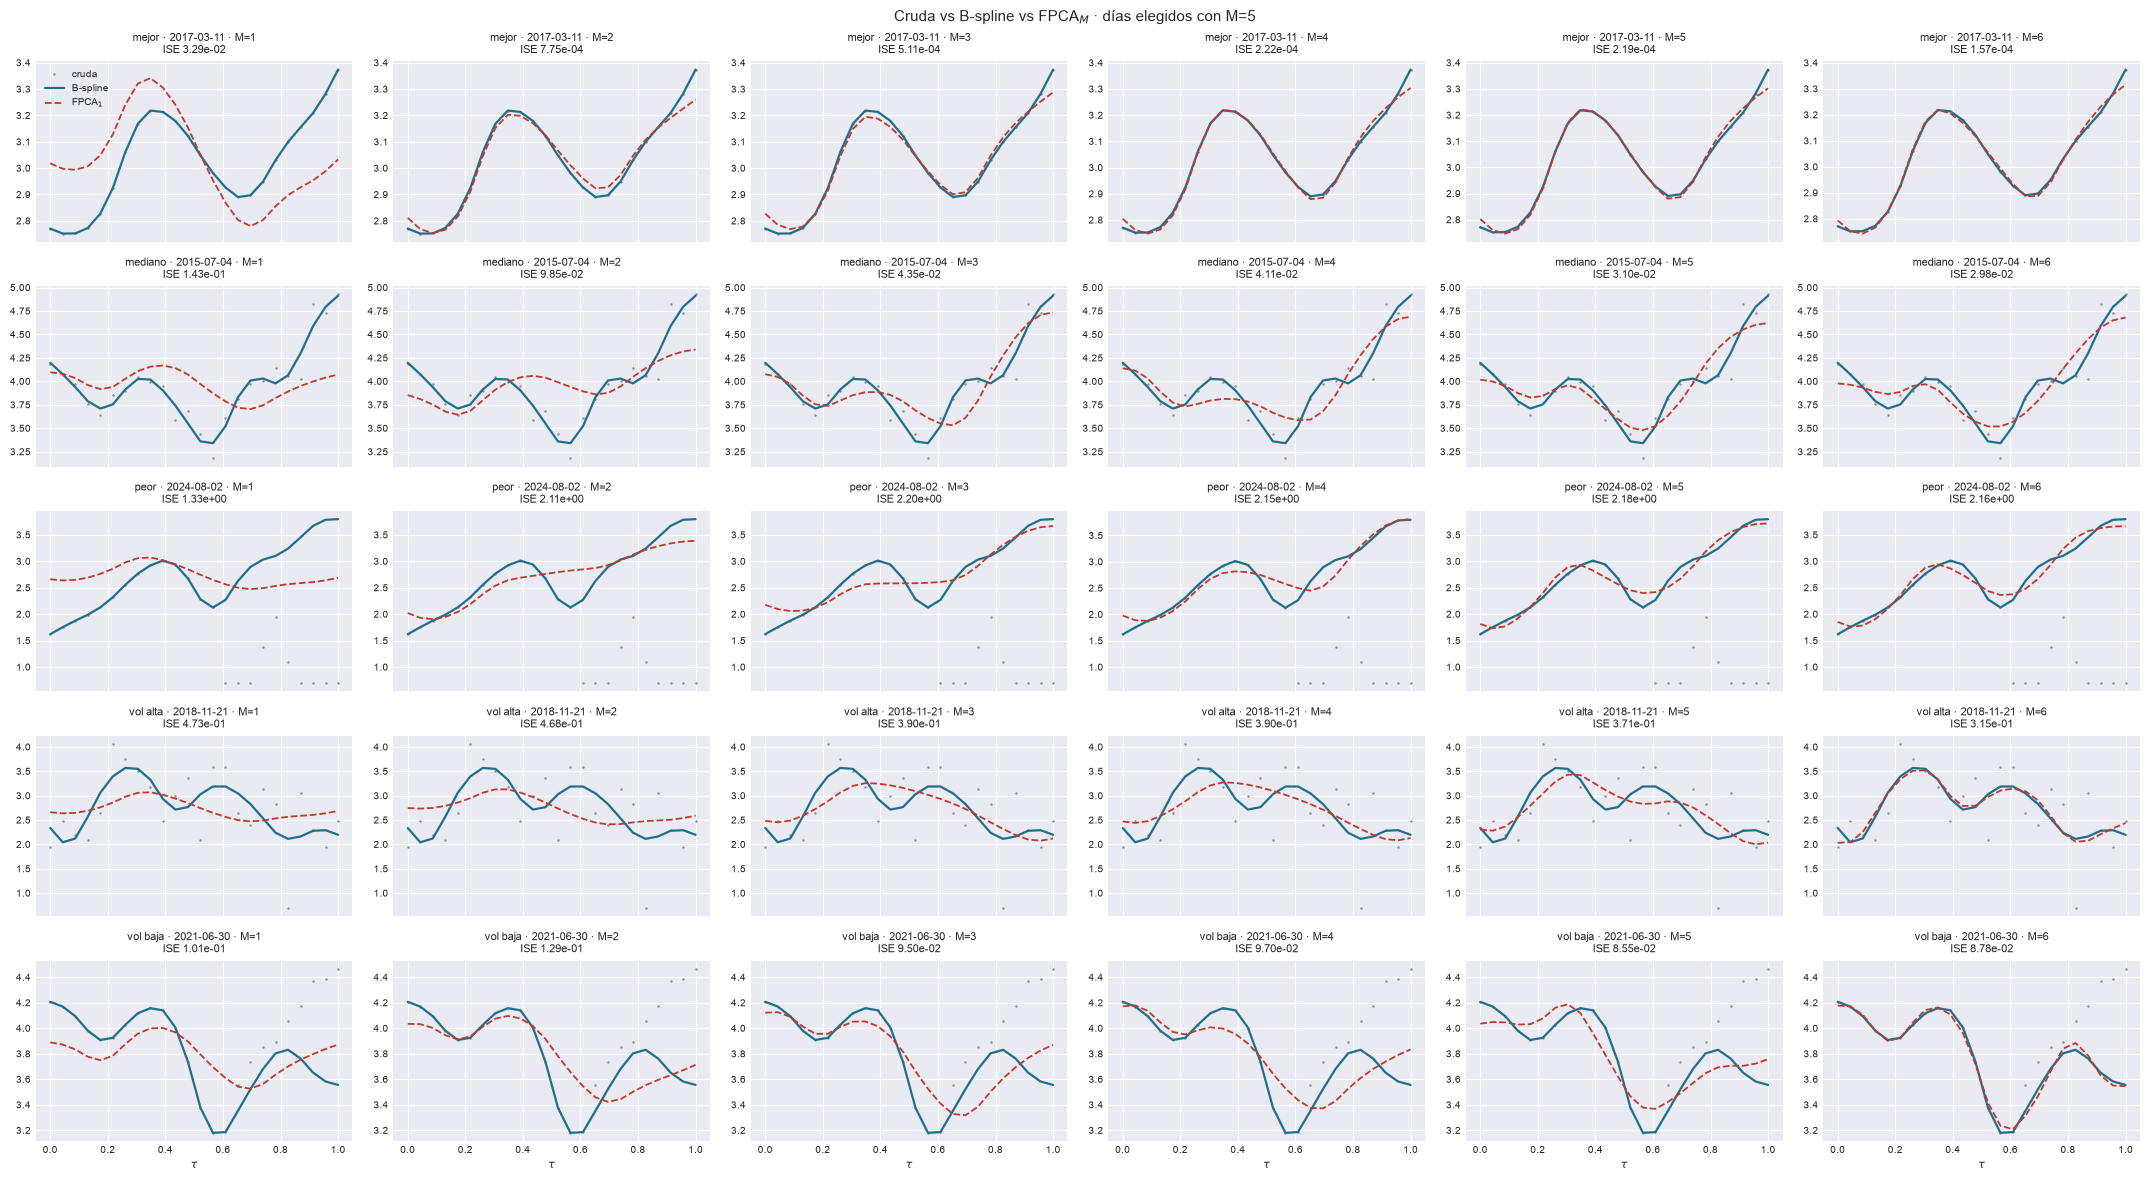

In [64]:
_w_tau = pesos_trapezoidales(grilla)
M_REF_DIAS = M_SUGERIDO if M_SUGERIDO in M_FPCA_LIST else min(M_FPCA_LIST)

X_FPCA = {}
filas_3c = []
for _M in M_FPCA_LIST:
    fpca.set_M(int(_M))
    X_FPCA[_M] = fpca.reconstruct(fpca.transform(THETA))      # (T, G)
    for bloque, _i in (("train", idx_train), ("test", idx_test)):
        _pc = mise(X[_i], X_SUAV[_i], grilla)
        _pf = mise(X[_i], X_FPCA[_M][_i], grilla)
        filas_3c.append({
            "M": int(_M), "bloque": bloque,
            "var_explicada": float(fpca.var_cum[_M - 1]),
            "mise_cruda_bspline": _pc,
            "mise_cruda_fpca": _pf,
            "mise_bspline_fpca": mise(X_SUAV[_i], X_FPCA[_M][_i], grilla),
            "frac_piso_base": _pc / _pf if _pf > 0 else np.nan,
        })

TRES_CURVAS = pd.DataFrame(filas_3c).set_index(["M", "bloque"])
for _p in PATHS_POR_M.values():
    TRES_CURVAS.to_csv(_p["out_report"] / "10_tres_curvas_mise.csv")
display(TRES_CURVAS.style
        .format({"var_explicada": "{:.4%}", "mise_cruda_bspline": "{:.3e}",
                 "mise_cruda_fpca": "{:.3e}", "mise_bspline_fpca": "{:.3e}",
                 "frac_piso_base": "{:.1%}"})
        .set_caption("Tres curvas · frac_piso_base = MISE(cruda, B-spline) / "
                     "MISE(cruda, FPCA_M) · diagnóstico, no métrica reportable"))

# Días de la figura: ISE por curva con la cuadratura común.
_ise = ((X - X_FPCA[M_REF_DIAS]) ** 2) @ _w_tau
_orden = np.argsort(_ise)
_cand = {"mejor": int(_orden[0]), "mediano": int(_orden[len(_orden) // 2]),
         "peor": int(_orden[-1]), "vol alta": int(np.nanargmax(VOL_DIA)),
         "vol baja": int(np.nanargmin(VOL_DIA))}
DIAS_3C = {}
for _nom, _i in _cand.items():
    if _i not in DIAS_3C.values():
        DIAS_3C[_nom] = _i

fig, axes = plt.subplots(len(DIAS_3C), len(M_FPCA_LIST),
                         figsize=(3.6 * len(M_FPCA_LIST), 2.4 * len(DIAS_3C)),
                         squeeze=False, sharex=True)
for r, (_nom, _i) in enumerate(DIAS_3C.items()):
    for c, _M in enumerate(M_FPCA_LIST):
        ax = axes[r, c]
        ax.plot(grilla, X[_i], ".", color="0.55", ms=1.5, label="cruda")
        ax.plot(grilla, X_SUAV[_i], color="#1f6f8b", lw=1.6, label="B-spline")
        ax.plot(grilla, X_FPCA[_M][_i], color="#c0392b", lw=1.3, ls="--",
                label=f"FPCA$_{{{_M}}}$")
        ax.set_title(f"{_nom} · {pd.Timestamp(DIAS[_i]).date()} · M={_M}\n"
                     f"ISE {(((X[_i] - X_FPCA[_M][_i]) ** 2) @ _w_tau):.2e}",
                     fontsize=8)
        ax.tick_params(labelsize=7)
axes[0, 0].legend(fontsize=7)
for ax in axes[-1]:
    ax.set_xlabel(r"$\tau$", fontsize=8)
fig.suptitle(f"Cruda vs B-spline vs FPCA$_M$ · días elegidos con M={M_REF_DIAS}",
             fontsize=11)
fig.tight_layout()
replicar_figura("10_tres_curvas.png", PATHS_POR_M, fig=fig)
plt.show()

## 4. El bucle sobre `M_FPCA_LIST`

- §4.1: `set_M(M)` y scores; contraste con la regla del 95 %
- §4.2: estandarizador en **identidad** (los scores van crudos) y artefactos FPCA
- §4.3: diagnóstico de rezagos sobre el bloque de entrenamiento
- §4.4: datasets AR con covariables **cruzadas** (un rezago)
- §4.5: hiperparámetros (Chung §4.2 en escala cruda) y `mcmc_config` — el contrato con MATLAB
- §4.6: `eval_config`, líneas base y `verificar_contrato`


In [65]:
def procesar_punto(M: int) -> dict:
    """Produce TODOS los artefactos del punto M del barrido y verifica su contrato.

    Recibe por clausura los objetos comunes de §2-§3.3 —`fpca` ya ajustado,
    `THETA`, `idx_train`/`idx_test`, `grilla`, `X_SUAV`— y no los recalcula:
    ésa es la garantía de que los puntos comparten datos y base.
    """
    PATHS = PATHS_POR_M[M]
    eid = eid_de(M)
    print(f"\n{'='*70}\nM = {M}   ·   {eid}\n{'='*70}")

    # -- §4.1 Componentes retenidas ------------------------------------------
    assert 1 <= M <= fpca.evals.size, f"M fuera de [1, {fpca.evals.size}]."
    coincide_regla = (M == M_SUGERIDO)
    print(f"M(95 %) según la regla : {M_SUGERIDO}   (K disponible = {fpca.evals.size})")
    print(f"M de este punto        : {M}"
          + ("   (coincide con la regla)" if coincide_regla
             else "   <- DIFIERE de la regla: es un punto de sensibilidad"))

    fpca.set_M(int(M))
    M_fpca = fpca.M

    SCORES       = fpca.transform(THETA)       # (T, M) — base ajustada en train
    SCORES_train = SCORES[idx_train]
    SCORES_test  = SCORES[idx_test]

    print(f"M = {M_fpca}   var. explicada = {fpca.var_cum[M_fpca-1]:.4%}")
    print(f"[train] max|media xi| = {np.abs(SCORES_train.mean(0)).max():.2e}   (~ 0)")
    print(f"[test]  max|media xi| = {np.abs(SCORES_test.mean(0)).max():.3f}")
    print(f"[test]  var xi / lambda = "
          f"{np.array2string(SCORES_test.var(0, ddof=1) / fpca.lambdas, precision=3)}")

    # -- §4.2 Escala de los scores: SIN estandarizar --------------------------
    # Se ajusta con train (verificar_contrato exige n_ajuste == T0) y se deja en
    # identidad: MATLAB recibe los scores en su escala propia.
    scores_standardizer = DataStandardizer(method="zscore_column", ddof=0)
    scores_standardizer.fit(SCORES_train, etiqueta=f"train[1:{T0}]")

    _chk = scores_standardizer.verificar_ajuste(T0)
    print(f"[holdout] ajustado con {_chk['n_ajuste']} filas = T0 "
          f"({_chk['etiqueta_ajuste']}) -> ok={_chk['ajuste_ok']}")

    MU_OBS = scores_standardizer.mean.copy()
    SD_OBS = scores_standardizer.std.copy()
    scores_standardizer.mean = np.zeros_like(MU_OBS)
    scores_standardizer.std  = np.ones_like(SD_OBS)

    SCORES_STD       = scores_standardizer.transform(SCORES)
    assert np.allclose(SCORES_STD, SCORES), "la transformacion deberia ser la identidad."
    SCORES_STD_train = SCORES_STD[idx_train]
    SCORES_STD_test  = SCORES_STD[idx_test]

    print(f"\nSCORES_STD {SCORES_STD.shape}   (= SCORES: transformacion identidad)")
    print(f"  [train] media = {np.array2string(MU_OBS, precision=3)}   <- NO se resta")
    print(f"  [train] std   = {np.array2string(SD_OBS, precision=3)}   <- NO se divide")
    print(f"  [test]  media = {np.array2string(SCORES_STD_test.mean(0), precision=3)}")
    print(f"  [test]  std   = {np.array2string(SCORES_STD_test.std(0),  precision=3)}")
    print(f"  rango que vera MATLAB: [{SCORES_STD.min():.3f}, {SCORES_STD.max():.3f}]")

    guardar_estandarizador(PATHS, scores_standardizer)
    _res = guardar_fpca(PATHS, fpca, SCORES, SCORES_STD=SCORES_STD,
                        meta_extra={"T0": int(T0)})
    print(f"\n[functional] artefactos FPCA · cond_W = {_res['meta']['cond_W']:.3e}")

    plot_diagnostico_estandarizacion(
        SCORES_train, SCORES_STD_train, np.arange(1, M_fpca + 1),
        labels=("Scores xi (escala lambda)", "Scores xi entregados (identicos: no se estandariza)"),
        title=f"estadísticas por componente FPCA (M={M})",
        save_path=str(PATHS["out_report"] / "08_diagnostico_estandarizacion.png"))
    plt.show()

    # -- §4.3 Diagnóstico de rezagos (sólo train) ----------------------------
    # Incluye los cruzados: muestra lo que el diseño de rezago propio descarta.
    N_LAGS_MAX = N_LAGS
    T_theta, K_total = SCORES_STD_train.shape

    def _spearman(Y, Xm):
        """Spearman columna a columna vía rangos (pandas, sin scipy)."""
        Yc = pd.DataFrame(Y).rank().to_numpy(); Yc = Yc - Yc.mean(0)
        Xc = pd.DataFrame(Xm).rank().to_numpy(); Xc = Xc - Xc.mean(0)
        return (Yc.T @ Xc) / np.outer(np.sqrt((Yc**2).sum(0)), np.sqrt((Xc**2).sum(0)))

    corr_p = np.zeros((K_total, K_total * N_LAGS_MAX))
    corr_s = np.zeros_like(corr_p)
    col_labels = []
    y_block = SCORES_STD_train[N_LAGS_MAX:, :]

    for lag in range(1, N_LAGS_MAX + 1):
        x_block = SCORES_STD_train[N_LAGS_MAX - lag : T_theta - lag, :]
        sp = _spearman(y_block, x_block)
        for j in range(K_total):
            c = (lag - 1) * K_total + j
            for k in range(K_total):
                corr_p[k, c] = np.corrcoef(y_block[:, k], x_block[:, j])[0, 1]
            corr_s[:, c] = sp[:, j]
            col_labels.append(rf"$\xi_{{t-{lag},{j+1}}}$")

    row_labels = [rf"$\xi_{{t,{k+1}}}$" for k in range(K_total)]
    band = 1.96 / np.sqrt(len(y_block))

    for M_corr, nombre, arch in ((corr_p, "Pearson", "09a"), (corr_s, "Spearman", "09b")):
        plot_rezagos_heatmap(
            M_corr, col_labels, row_labels,
            title=f"{nombre} — respuesta($t$) vs rezagos 1..{N_LAGS_MAX}  (M={M})",
            n_lags_max=N_LAGS_MAX, K_total=K_total, band=band, vclip=0.6,
            save_path=str(PATHS["out_report"] / f"{arch}_rezagos_{nombre.lower()}.png"))
        plt.show()

    # -- §4.4 Datasets AR: covariables CRUZADAS (todas las componentes, un rezago) --
    COMPONENT_IDX = list(range(SCORES_STD.shape[1]))   # base-0; los nombres usan idx+1

    n_components = len(COMPONENT_IDX)
    n_train_eff  = T0 - N_LAGS
    n_test_eff   = T - T0

    assert T0 > N_LAGS and len(set(COMPONENT_IDX)) == n_components

    # cov_names en orden lag-mayor (lo exige _cols_orden del _05).
    cov_names = [f"fpc_{COMPONENT_IDX[j] + 1}_lag{lag}"
                 for lag in range(1, N_LAGS + 1)
                 for j in range(n_components)]
    cov_por_comp = {k: list(cov_names) for k in range(n_components)}

    # Cruzados: cada componente ve las covariables de TODAS (p = M x N_LAGS).
    for k, covs in cov_por_comp.items():
        assert covs == cov_names and len(covs) == n_components * N_LAGS, (
            f"FPC {COMPONENT_IDX[k] + 1}: se esperaban las {n_components * N_LAGS} covariables cruzadas.")

    print(f"componentes : {n_components} -> índices {COMPONENT_IDX}")
    print(f"N_LAGS      : {N_LAGS}   ·   p = {len(cov_por_comp[0])} covariable(s) por componente (cruzadas)")
    print(f"n_train_eff : {n_train_eff}   n_test_eff : {n_test_eff}")
    print(f"cov_por_comp: {cov_por_comp}")

    SCORES_sel = SCORES_STD[:, COMPONENT_IDX]

    def _dataset_bloque(k, t_ini, t_fin):
        """Respuesta en t en [t_ini, t_fin) y predictores xi_1..xi_M en t-1 ... t-N_LAGS."""
        t_idx  = np.arange(t_ini, t_fin)
        X_cols = np.hstack([SCORES_sel[t_idx - lag, :] for lag in range(1, N_LAGS + 1)])
        return pd.DataFrame(np.column_stack([SCORES_sel[t_idx, k], X_cols]),
                            columns=[f"fpc_{COMPONENT_IDX[k] + 1}"] + cov_por_comp[k])

    dfs_train = {k: _dataset_bloque(k, N_LAGS, T0) for k in range(n_components)}
    dfs_test  = {k: _dataset_bloque(k, T0,     T)  for k in range(n_components)}

    manifest = {
        "scores_scale":  "raw_fpca_scores",
        "n_components":  n_components,
        "n_lags":        int(N_LAGS),
        "component_idx": [int(i) for i in COMPONENT_IDX],
        "cov_names":     cov_names,
        "cov_por_componente": {str(k): cov_por_comp[k] for k in range(n_components)},
        "covariables":   "todos_los_rezagos",
        "T": int(T), "T0": int(T0), "prop_train": float(PROP_TRAIN),
        "n_train_eff": int(n_train_eff), "n_test_eff": int(n_test_eff),
        "ajuste_en": "train",
    }
    guardar_datasets_ar(PATHS, dfs_train, dfs_test, manifest)
    print(f"[functional] {2*n_components} datasets + datasets_manifest.json")
    for k in range(n_components):
        print(f"  fpc_{COMPONENT_IDX[k]+1}: train {dfs_train[k].shape} · test {dfs_test[k].shape}")

    # -- §4.5 Hiperparametros y MCMC ------------------------------------------
    # Chung §4.2 en escala cruda, con las sd de TRAIN: btau y taupsij escalan con la
    # varianza de cada componente; mupsij = 0. El tipo sale del nombre fpc_<idx>_lag<l>:
    # own_lag<l> si <idx> es la componente modelada, cross_lag<l> si es otra.
    def _clasificar(nombre, k_modelo):
        idx, lag = nombre[len("fpc_"):].split("_lag")
        return f"{'own' if int(idx) == COMPONENT_IDX[k_modelo] + 1 else 'cross'}_lag{int(lag)}"

    def _beta_pi(nombre, k_modelo):
        cfg = HP_BY_TYPE[_clasificar(nombre, k_modelo)]
        return float(cfg["apij"]), float(cfg["bpij"])

    HYPERPARAMS_LIST = []
    for k in range(n_components):
        sd_y = float(SCORES_train[:, k].std(ddof=0))
        sd_x = dfs_train[k][cov_por_comp[k]].to_numpy().std(axis=0, ddof=0)
        _ab  = [_beta_pi(nm, k) for nm in cov_por_comp[k]]
        HYPERPARAMS_LIST.append({**HP_GLOBAL,
            "btau":    HP_CHUNG_ESC["btau_z"] * sd_y ** 2,
            "apij":    np.array([a for a, _ in _ab], dtype=float),
            "bpij":    np.array([b for _, b in _ab], dtype=float),
            "mupsij":  np.zeros(len(cov_por_comp[k])),
            "taupsij": HP_CHUNG_ESC["taupsij_z"] * sd_x ** 2})

    print(f"\nN_CHAINS = {N_CHAINS} cadenas por componente "
          f"-> {N_CHAINS * n_components} jobs en MATLAB si se entrena este M")
    print(f"  {'k':>2} {'fpc':>4} {'var(y)':>11} {'E[tau]':>10} {'btau':>11}  taupsij")
    for k in range(n_components):
        hp = HYPERPARAMS_LIST[k]
        print(f"  {k:>2} {COMPONENT_IDX[k]+1:>4} {SCORES_train[:, k].var(ddof=0):>11.4e} "
              f"{hp['atau']/hp['btau']:>10.3e} {hp['btau']:>11.4e}  "
              f"{np.array2string(hp['taupsij'], precision=3)}")

    hp_artifact = {
        "global":       HP_GLOBAL,
        "by_type":      HP_BY_TYPE,
        "variante":     {"nombre": VARIANTE, **VAR_CFG,
                         "grid_gamma": "por_predictor_rango_train_con_extremos",
                         "chung_escala_cruda": {**HP_CHUNG_ESC,
                             "ab_por_lag": {str(l): v for l, v in HP_CHUNG_ESC["ab_por_lag"].items()}}},
        "mcmc_config":  MCMC_CONFIG,
        "n_iter":       N_CHAINS,
        "seed_scheme":  "seed_base + chain*9973 + k*31",
        "serie_id":     SERIE_ID,
        "ventana_id":   int(VENTANA_ID),
        "m_fpca":       int(M),
        "m_entrenamiento": int(M),          # cruzados: cada M se entrena
        "trazas_en":    eid,
        "covariables":  "todos_los_rezagos",
        "seed_base":    int(SEED),     # MATLAB la lee de aquí
        "scores_scale": "raw_fpca_scores",
        "partition": {
            "T": int(T), "T0": int(T0), "prop_train": float(PROP_TRAIN),
            "n_train_eff": int(n_train_eff), "n_test_eff": int(n_test_eff),
            "train_files": [f"dataset_fpc_{COMPONENT_IDX[k]+1}_train.csv"
                            for k in range(n_components)],
            "test_files":  [f"dataset_fpc_{COMPONENT_IDX[k]+1}_test.csv"
                            for k in range(n_components)],
        },
        "hyperparams_list": [
            {"component_k": k, "fpc_idx": int(COMPONENT_IDX[k] + 1),
             "hyperparams": {key: (v.tolist() if isinstance(v, np.ndarray) else v)
                             for key, v in HYPERPARAMS_LIST[k].items()}}
            for k in range(n_components)
        ],
    }
    guardar_hiperparametros(PATHS, hp_artifact)
    print(f"[out_artefact] hyperparameters.json -> {PATHS['out_artefact']}")

    # -- §4.6 Evaluación, líneas base y contrato -----------------------------
    eval_config = {
        "scheme":      "holdout_temporal",
        "T": int(T), "T0": int(T0), "prop_train": float(PROP_TRAIN),
        "horizons":    [1],
        "n_lags":      int(N_LAGS),
        "m_fpca":      int(M),
        "scores_scale": "raw_fpca_scores",
        "fuente":              f"datos observados (SINCA, PM2.5 horario, {ESTACION})",
        "curva":               CURVA,
        "variable":            VARIABLE,
        # docs 03_05_00: ninguno es la grilla cruda.
        #   principal  : curva suavizada = representacion B-spline de la observada
        #   secundario : X_t^(M), la expansion truncada; solo metodos sobre scores
        "objetivo_evaluacion": "curva_suavizada",
        "objetivo_secundario": "representacion_fpca",
        # Forzado por el modelo, no es perilla: la variabilidad vive en la mezcla.
        "modo_residuo":        "ninguno",
        "nivel_credibilidad":  0.95,
        "ventana_movil": {"w": [20, 30, 40], "paso": 1, "solapadas": True},
        # Las metricas del marco teorico 02_02_03, y solo esas.
        "metricas_bloque_A": ["mae_f", "rmse_f", "linf_medio", "linf_max"],
        "metricas_bloque_B": ["mpiw", "picp", "picp_simultaneo", "winkler",
                              "winkler_max_medio", "winkler_max_glob"],
    }
    guardar_config_evaluacion(PATHS, eval_config)
    print("[out_artefact] eval_config.json")

    # Líneas base a h=1: el piso que el PSBP-FD debe superar.
    baselines_df = tabla_baselines(SCORES_STD, T0, estandarizador=scores_standardizer,
                                   fpca=fpca, X_obs=X_SUAV, tau=grilla, h=1)
    baselines_df.to_csv(PATHS["out_report"] / "30_baselines_test.csv")
    display(baselines_df.style.format("{:.4f}", na_rep="-")
            .set_caption(f"Líneas base (M={M}) — prueba, h=1, contra la curva SUAVIZADA"))

    informe = verificar_contrato(PATHS)
    print(f"contrato_ok = {informe['contrato_ok']}   "
          f"(M={informe['M']}, K={informe['K']}, T0={informe['T0']}, "
          f"n_components={informe['n_components']})")
    print(f"estandarizador ajustado con {informe.get('estandarizador_n_ajuste')} filas "
          f"(T0={informe['T0']})")
    print(f"verificación FPCA: todo_ok = {informe['verificacion_fpca']['todo_ok']}")
    if not informe["contrato_ok"]:
        print("\nPROBLEMAS:")
        for p in informe.get("problemas", []):
            print(f"  - {p}")

    return {
        "M": int(M),
        "experiment_id": eid,
        "var_acum": float(fpca.var_cum[M_fpca - 1]),
        "K": int(fpca.evals.size),
        "coincide_regla_95": bool(coincide_regla),
        "n_components": int(n_components),
        "p_covariables": int(len(cov_por_comp[0])),
        "contrato_ok": bool(informe["contrato_ok"]),
        "problemas": informe.get("problemas", []),
    }

VARIANTE 'chungEscG': HP_GLOBAL={'atau': 2.0, 'btau': 0.5, 'ag': 0.5, 'bg': 0.5, 'mumu': 0.0, 'taumu': 1.0, 'pwj': 0.5}
  own_lag1: apij=1.0, bpij=5.0  E[pi]=0.167
  cross_lag1: apij=1.0, bpij=5.0  E[pi]=0.167
N=30  ·  mupsij=0, taupsij=10*sd_x^2, btau=0.5*sd_y^2 (Chung en escala cruda)
N_LAGS=1  ·  MCMC_CONFIG={'nsim': 2500, 'burn': 500, 'N': 30, 'M': 50}  ·  N_CHAINS=1
Draws posteriores por score: (2500 - 500) x 1 = 2000

M = 1   ·   real_pm25_poh_v02_m01
M(95 %) según la regla : 5   (K disponible = 10)
M de este punto        : 1   <- DIFIERE de la regla: es un punto de sensibilidad
M = 1   var. explicada = 76.6746%
[train] max|media xi| = 8.07e-16   (~ 0)
[test]  max|media xi| = 0.190
[test]  var xi / lambda = [1.056]
[holdout] ajustado con 2922 filas = T0 (train[1:2922]) -> ok=True

SCORES_STD (4018, 1)   (= SCORES: transformacion identidad)
  [train] media = [8.073e-16]   <- NO se resta
  [train] std   = [0.578]   <- NO se divide
  [test]  media = [0.19]
  [test]  std   = [0.594]


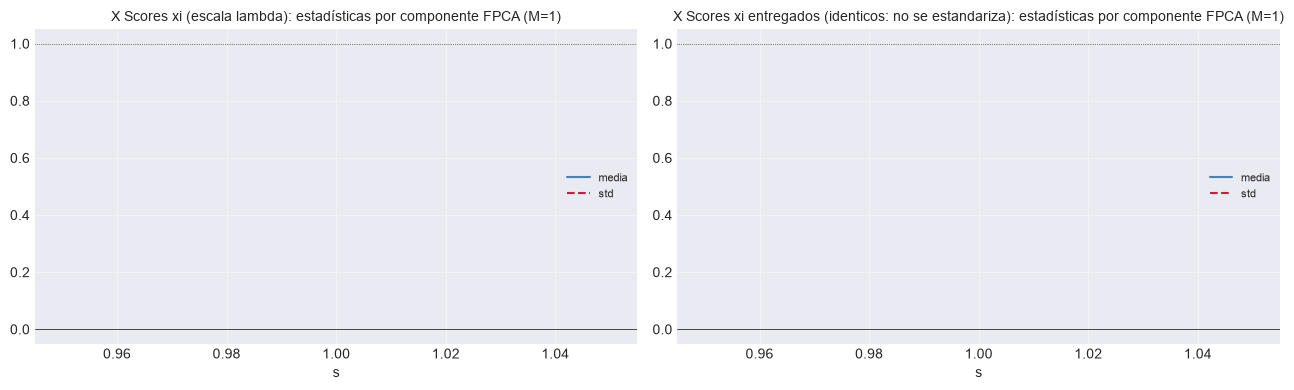

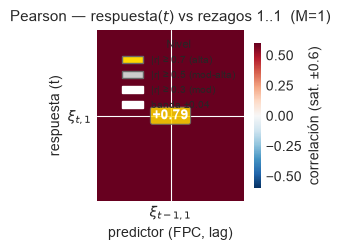

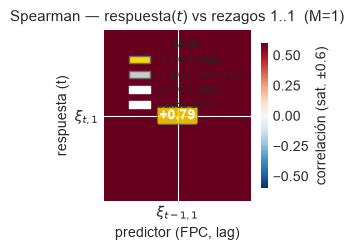

componentes : 1 -> índices [0]
N_LAGS      : 1   ·   p = 1 covariable(s) por componente (cruzadas)
n_train_eff : 2921   n_test_eff : 1096
cov_por_comp: {0: ['fpc_1_lag1']}
[functional] 2 datasets + datasets_manifest.json
  fpc_1: train (2921, 2) · test (1096, 2)

N_CHAINS = 1 cadenas por componente -> 1 jobs en MATLAB si se entrena este M
   k  fpc      var(y)     E[tau]        btau  taupsij
   0    1  3.3439e-01  1.196e+01  1.6719e-01  [3.345]
[out_artefact] hyperparameters.json -> C:\Users\56jua\Desktop\git_tesis\bayesian_non_parametrics-1\artefact\reales\real_pm25_poh_v02_m01
[out_artefact] eval_config.json


,n_test,RMSE_fpc1,RMSE_scores_prom,R2_scores_prom,MISE,RMSE_funcional
modelo,,,,,,
media_incondicional,1096.0000,0.6236,0.6236,-0.1023,0.5000,0.7071
persistencia_lag1,1096.0000,0.3863,0.3863,0.5771,0.2603,0.5102


contrato_ok = True   (M=1, K=10, T0=2922, n_components=1)
estandarizador ajustado con 2922 filas (T0=2922)
verificación FPCA: todo_ok = True

M = 2   ·   real_pm25_poh_v02_m02
M(95 %) según la regla : 5   (K disponible = 10)
M de este punto        : 2   <- DIFIERE de la regla: es un punto de sensibilidad
M = 2   var. explicada = 86.3636%
[train] max|media xi| = 8.72e-16   (~ 0)
[test]  max|media xi| = 0.190
[test]  var xi / lambda = [1.056 1.131]
[holdout] ajustado con 2922 filas = T0 (train[1:2922]) -> ok=True

SCORES_STD (4018, 2)   (= SCORES: transformacion identidad)
  [train] media = [ 8.718e-16 -4.243e-16]   <- NO se resta
  [train] std   = [0.578 0.206]   <- NO se divide
  [test]  media = [ 0.19  -0.007]
  [test]  std   = [0.594 0.219]
  rango que vera MATLAB: [-1.508, 2.402]

[functional] artefactos FPCA · cond_W = 8.435e+00


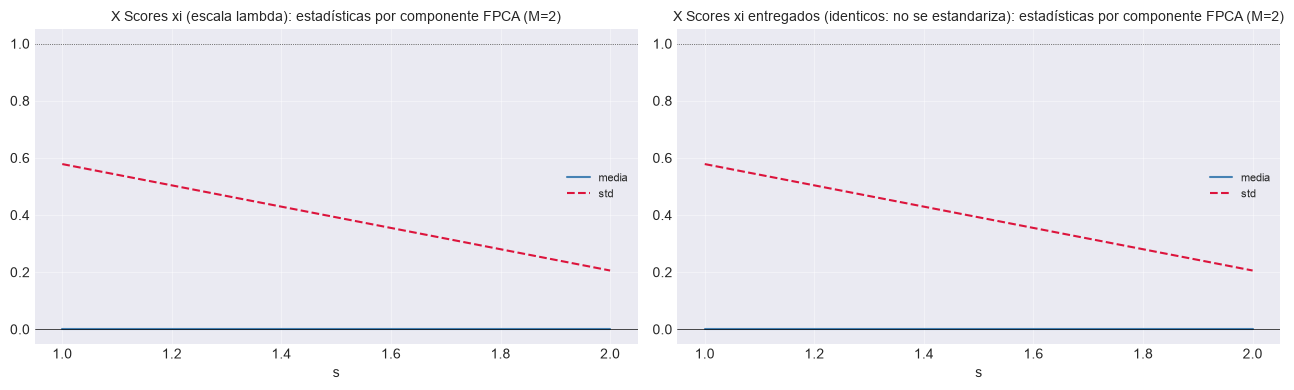

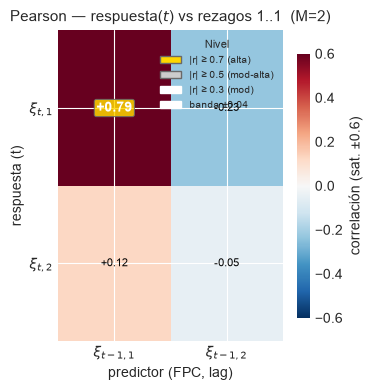

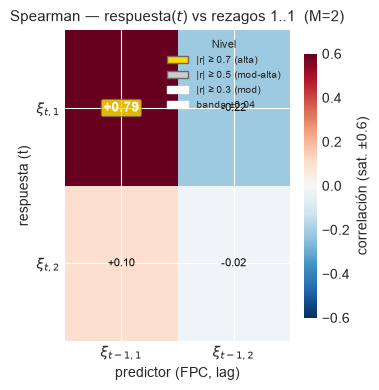

componentes : 2 -> índices [0, 1]
N_LAGS      : 1   ·   p = 2 covariable(s) por componente (cruzadas)
n_train_eff : 2921   n_test_eff : 1096
cov_por_comp: {0: ['fpc_1_lag1', 'fpc_2_lag1'], 1: ['fpc_1_lag1', 'fpc_2_lag1']}
[functional] 4 datasets + datasets_manifest.json
  fpc_1: train (2921, 3) · test (1096, 3)
  fpc_2: train (2921, 3) · test (1096, 3)

N_CHAINS = 1 cadenas por componente -> 2 jobs en MATLAB si se entrena este M
   k  fpc      var(y)     E[tau]        btau  taupsij
   0    1  3.3439e-01  1.196e+01  1.6719e-01  [3.345 0.423]
   1    2  4.2255e-02  9.466e+01  2.1127e-02  [3.345 0.423]
[out_artefact] hyperparameters.json -> C:\Users\56jua\Desktop\git_tesis\bayesian_non_parametrics-1\artefact\reales\real_pm25_poh_v02_m02
[out_artefact] eval_config.json


,n_test,RMSE_fpc1,RMSE_fpc2,RMSE_scores_prom,R2_scores_prom,MISE,RMSE_funcional
modelo,,,,,,,
media_incondicional,1096.0000,0.6236,0.2186,0.4211,-0.0516,0.5000,0.7071
persistencia_lag1,1096.0000,0.3863,0.3052,0.3457,-0.1867,0.3056,0.5528


contrato_ok = True   (M=2, K=10, T0=2922, n_components=2)
estandarizador ajustado con 2922 filas (T0=2922)
verificación FPCA: todo_ok = True

M = 3   ·   real_pm25_poh_v02_m03
M(95 %) según la regla : 5   (K disponible = 10)
M de este punto        : 3   <- DIFIERE de la regla: es un punto de sensibilidad
M = 3   var. explicada = 91.9030%
[train] max|media xi| = 8.72e-16   (~ 0)
[test]  max|media xi| = 0.190
[test]  var xi / lambda = [1.056 1.131 0.955]
[holdout] ajustado con 2922 filas = T0 (train[1:2922]) -> ok=True

SCORES_STD (4018, 3)   (= SCORES: transformacion identidad)
  [train] media = [ 8.718e-16 -4.243e-16  4.797e-16]   <- NO se resta
  [train] std   = [0.578 0.206 0.155]   <- NO se divide
  [test]  media = [ 0.19  -0.007  0.028]
  [test]  std   = [0.594 0.219 0.152]
  rango que vera MATLAB: [-1.508, 2.402]

[functional] artefactos FPCA · cond_W = 8.435e+00


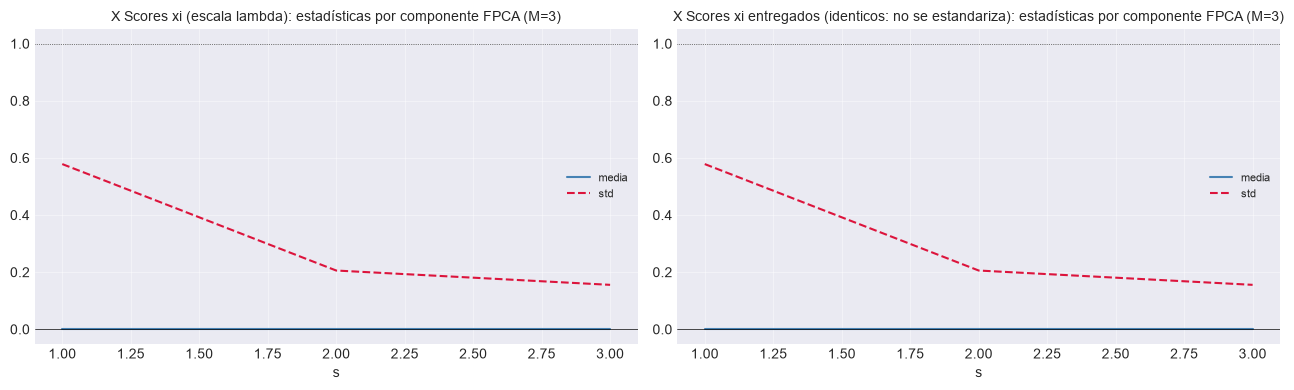

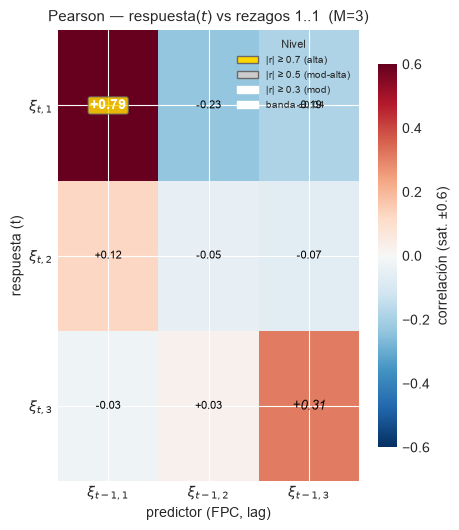

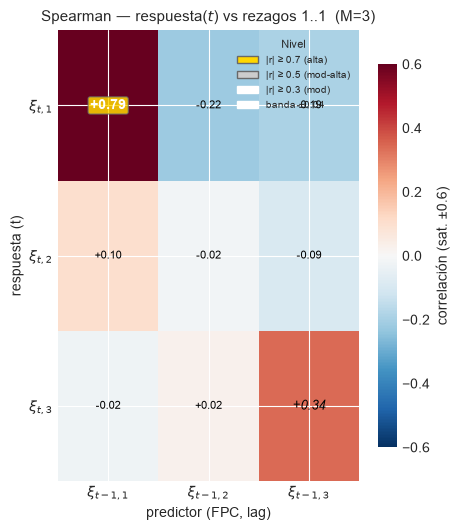

componentes : 3 -> índices [0, 1, 2]
N_LAGS      : 1   ·   p = 3 covariable(s) por componente (cruzadas)
n_train_eff : 2921   n_test_eff : 1096
cov_por_comp: {0: ['fpc_1_lag1', 'fpc_2_lag1', 'fpc_3_lag1'], 1: ['fpc_1_lag1', 'fpc_2_lag1', 'fpc_3_lag1'], 2: ['fpc_1_lag1', 'fpc_2_lag1', 'fpc_3_lag1']}
[functional] 6 datasets + datasets_manifest.json
  fpc_1: train (2921, 4) · test (1096, 4)
  fpc_2: train (2921, 4) · test (1096, 4)
  fpc_3: train (2921, 4) · test (1096, 4)

N_CHAINS = 1 cadenas por componente -> 3 jobs en MATLAB si se entrena este M
   k  fpc      var(y)     E[tau]        btau  taupsij
   0    1  3.3439e-01  1.196e+01  1.6719e-01  [3.345 0.423 0.242]
   1    2  4.2255e-02  9.466e+01  2.1127e-02  [3.345 0.423 0.242]
   2    3  2.4158e-02  1.656e+02  1.2079e-02  [3.345 0.423 0.242]
[out_artefact] hyperparameters.json -> C:\Users\56jua\Desktop\git_tesis\bayesian_non_parametrics-1\artefact\reales\real_pm25_poh_v02_m03
[out_artefact] eval_config.json


,n_test,RMSE_fpc1,RMSE_fpc2,RMSE_fpc3,RMSE_scores_prom,R2_scores_prom,MISE,RMSE_funcional
modelo,,,,,,,,
media_incondicional,1096.0000,0.6236,0.2186,0.1544,0.3322,-0.0456,0.5000,0.7071
persistencia_lag1,1096.0000,0.3863,0.3052,0.1808,0.2907,-0.2635,0.3145,0.5608


contrato_ok = True   (M=3, K=10, T0=2922, n_components=3)
estandarizador ajustado con 2922 filas (T0=2922)
verificación FPCA: todo_ok = True

M = 4   ·   real_pm25_poh_v02_m04
M(95 %) según la regla : 5   (K disponible = 10)
M de este punto        : 4   <- DIFIERE de la regla: es un punto de sensibilidad
M = 4   var. explicada = 94.5849%
[train] max|media xi| = 8.72e-16   (~ 0)
[test]  max|media xi| = 0.190
[test]  var xi / lambda = [1.056 1.131 0.955 1.11 ]
[holdout] ajustado con 2922 filas = T0 (train[1:2922]) -> ok=True

SCORES_STD (4018, 4)   (= SCORES: transformacion identidad)
  [train] media = [ 8.718e-16 -4.243e-16  4.797e-16 -6.294e-16]   <- NO se resta
  [train] std   = [0.578 0.206 0.155 0.108]   <- NO se divide
  [test]  media = [ 0.19  -0.007  0.028 -0.013]
  [test]  std   = [0.594 0.219 0.152 0.114]
  rango que vera MATLAB: [-1.508, 2.402]

[functional] artefactos FPCA · cond_W = 8.435e+00


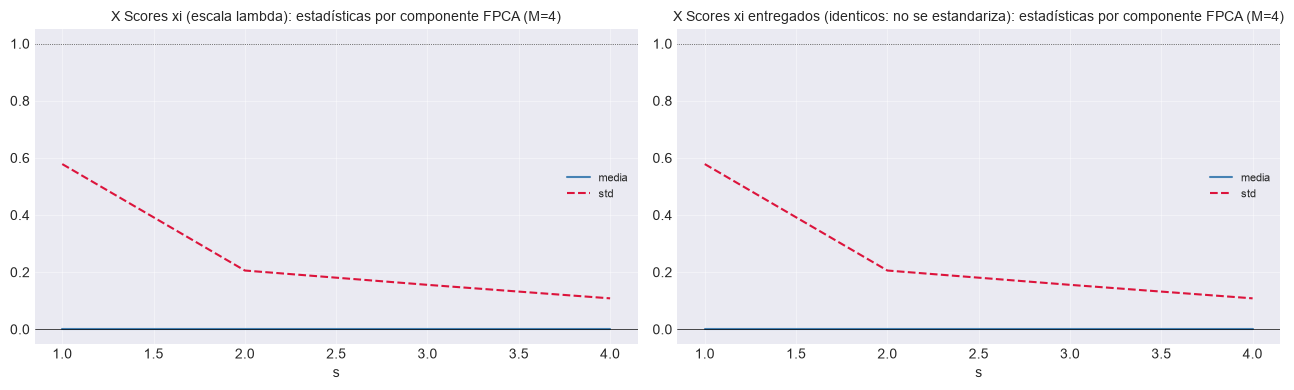

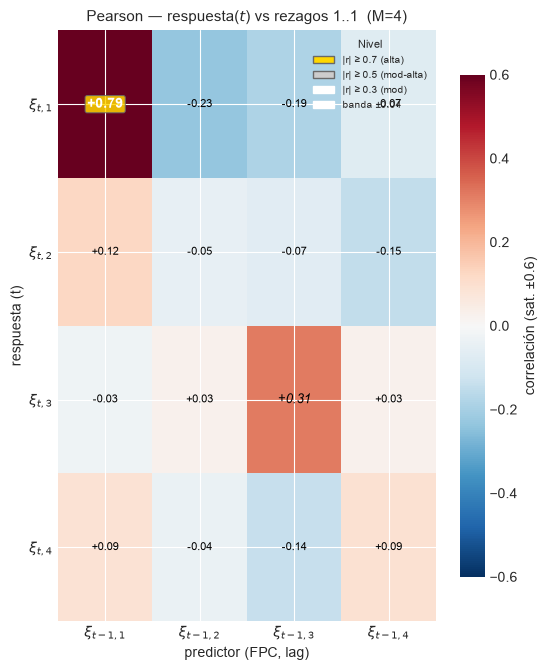

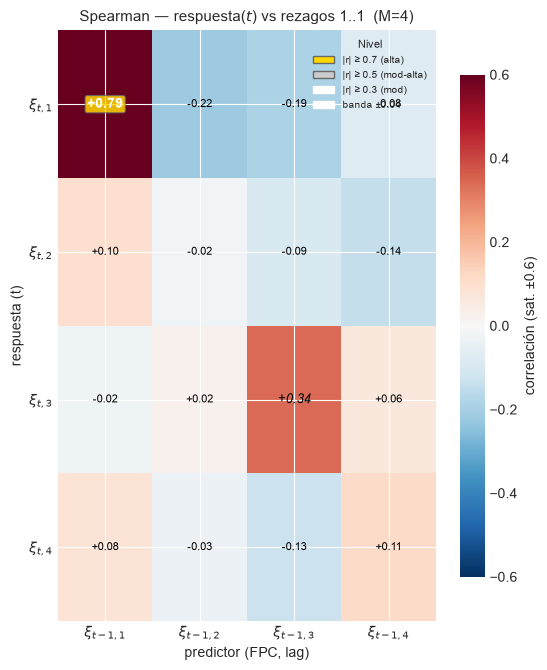

componentes : 4 -> índices [0, 1, 2, 3]
N_LAGS      : 1   ·   p = 4 covariable(s) por componente (cruzadas)
n_train_eff : 2921   n_test_eff : 1096
cov_por_comp: {0: ['fpc_1_lag1', 'fpc_2_lag1', 'fpc_3_lag1', 'fpc_4_lag1'], 1: ['fpc_1_lag1', 'fpc_2_lag1', 'fpc_3_lag1', 'fpc_4_lag1'], 2: ['fpc_1_lag1', 'fpc_2_lag1', 'fpc_3_lag1', 'fpc_4_lag1'], 3: ['fpc_1_lag1', 'fpc_2_lag1', 'fpc_3_lag1', 'fpc_4_lag1']}
[functional] 8 datasets + datasets_manifest.json
  fpc_1: train (2921, 5) · test (1096, 5)
  fpc_2: train (2921, 5) · test (1096, 5)
  fpc_3: train (2921, 5) · test (1096, 5)
  fpc_4: train (2921, 5) · test (1096, 5)

N_CHAINS = 1 cadenas por componente -> 4 jobs en MATLAB si se entrena este M
   k  fpc      var(y)     E[tau]        btau  taupsij
   0    1  3.3439e-01  1.196e+01  1.6719e-01  [3.345 0.423 0.242 0.117]
   1    2  4.2255e-02  9.466e+01  2.1127e-02  [3.345 0.423 0.242 0.117]
   2    3  2.4158e-02  1.656e+02  1.2079e-02  [3.345 0.423 0.242 0.117]
   3    4  1.1696e-02  3.420e

,n_test,RMSE_fpc1,RMSE_fpc2,RMSE_fpc3,RMSE_fpc4,RMSE_scores_prom,R2_scores_prom,MISE,RMSE_funcional
modelo,,,,,,,,,
media_incondicional,1096.0000,0.6236,0.2186,0.1544,0.1147,0.2778,-0.0376,0.5000,0.7071
persistencia_lag1,1096.0000,0.3863,0.3052,0.1808,0.1540,0.2566,-0.4050,0.3251,0.5702


contrato_ok = True   (M=4, K=10, T0=2922, n_components=4)
estandarizador ajustado con 2922 filas (T0=2922)
verificación FPCA: todo_ok = True

M = 5   ·   real_pm25_poh_v02_m05
M(95 %) según la regla : 5   (K disponible = 10)
M de este punto        : 5   (coincide con la regla)
M = 5   var. explicada = 96.3528%
[train] max|media xi| = 1.31e-15   (~ 0)
[test]  max|media xi| = 0.190
[test]  var xi / lambda = [1.056 1.131 0.955 1.11  1.017]
[holdout] ajustado con 2922 filas = T0 (train[1:2922]) -> ok=True

SCORES_STD (4018, 5)   (= SCORES: transformacion identidad)
  [train] media = [ 8.718e-16 -4.243e-16  4.797e-16 -6.294e-16 -1.313e-15]   <- NO se resta
  [train] std   = [0.578 0.206 0.155 0.108 0.088]   <- NO se divide
  [test]  media = [ 0.19  -0.007  0.028 -0.013  0.018]
  [test]  std   = [0.594 0.219 0.152 0.114 0.089]
  rango que vera MATLAB: [-1.508, 2.402]

[functional] artefactos FPCA · cond_W = 8.435e+00


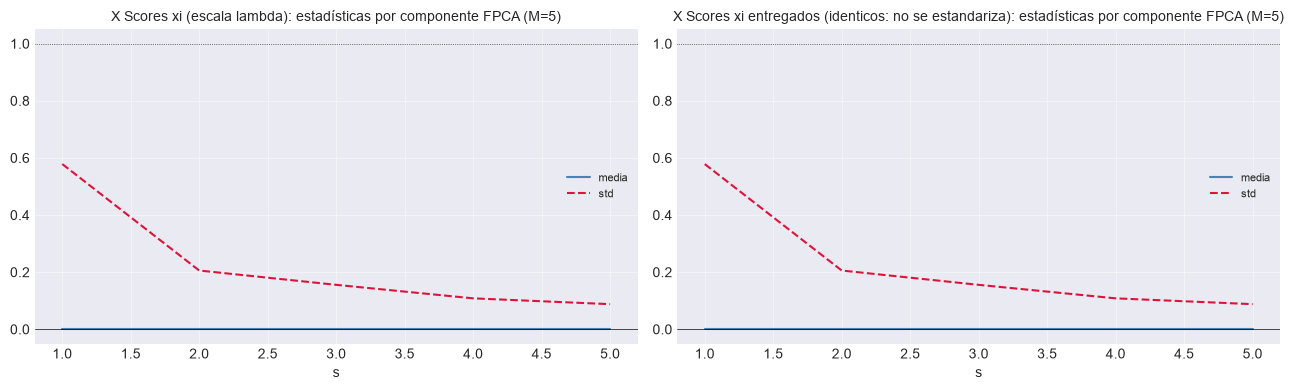

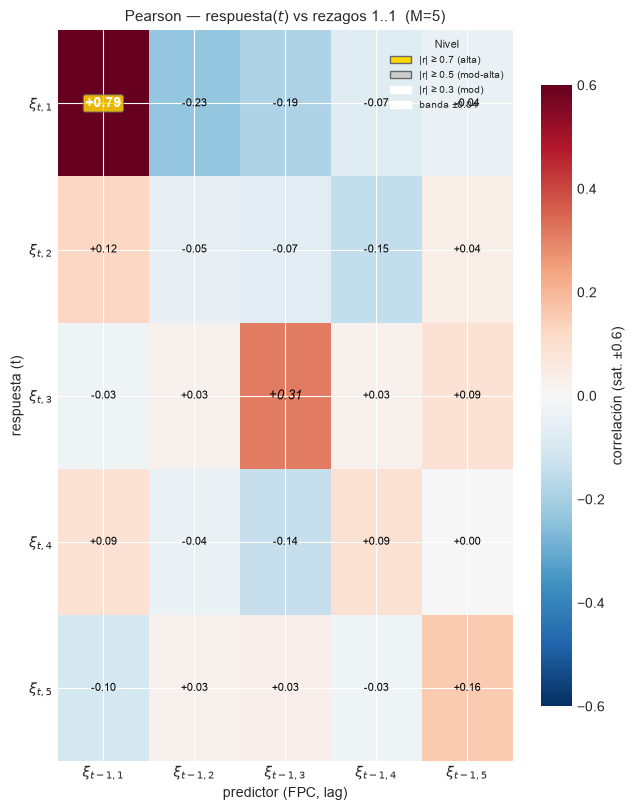

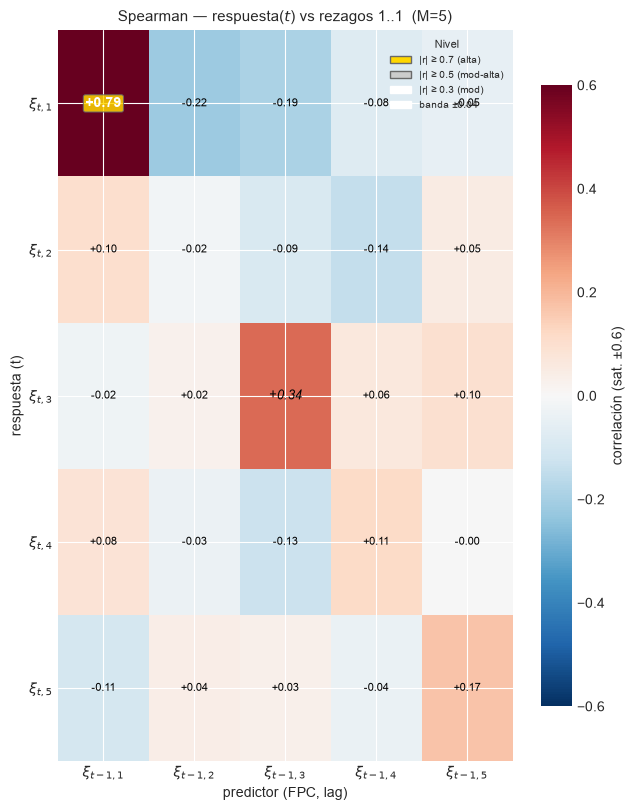

componentes : 5 -> índices [0, 1, 2, 3, 4]
N_LAGS      : 1   ·   p = 5 covariable(s) por componente (cruzadas)
n_train_eff : 2921   n_test_eff : 1096
cov_por_comp: {0: ['fpc_1_lag1', 'fpc_2_lag1', 'fpc_3_lag1', 'fpc_4_lag1', 'fpc_5_lag1'], 1: ['fpc_1_lag1', 'fpc_2_lag1', 'fpc_3_lag1', 'fpc_4_lag1', 'fpc_5_lag1'], 2: ['fpc_1_lag1', 'fpc_2_lag1', 'fpc_3_lag1', 'fpc_4_lag1', 'fpc_5_lag1'], 3: ['fpc_1_lag1', 'fpc_2_lag1', 'fpc_3_lag1', 'fpc_4_lag1', 'fpc_5_lag1'], 4: ['fpc_1_lag1', 'fpc_2_lag1', 'fpc_3_lag1', 'fpc_4_lag1', 'fpc_5_lag1']}
[functional] 10 datasets + datasets_manifest.json
  fpc_1: train (2921, 6) · test (1096, 6)
  fpc_2: train (2921, 6) · test (1096, 6)
  fpc_3: train (2921, 6) · test (1096, 6)
  fpc_4: train (2921, 6) · test (1096, 6)
  fpc_5: train (2921, 6) · test (1096, 6)

N_CHAINS = 1 cadenas por componente -> 5 jobs en MATLAB si se entrena este M
   k  fpc      var(y)     E[tau]        btau  taupsij
   0    1  3.3439e-01  1.196e+01  1.6719e-01  [3.345 0.423 0.242 0.1

,n_test,RMSE_fpc1,RMSE_fpc2,RMSE_fpc3,RMSE_fpc4,RMSE_fpc5,RMSE_scores_prom,R2_scores_prom,MISE,RMSE_funcional
modelo,,,,,,,,,,
media_incondicional,1096.0000,0.6236,0.2186,0.1544,0.1147,0.0904,0.2403,-0.0385,0.5000,0.7071
persistencia_lag1,1096.0000,0.3863,0.3052,0.1808,0.1540,0.1132,0.2279,-0.4506,0.3297,0.5742


contrato_ok = True   (M=5, K=10, T0=2922, n_components=5)
estandarizador ajustado con 2922 filas (T0=2922)
verificación FPCA: todo_ok = True

M = 6   ·   real_pm25_poh_v02_m06
M(95 %) según la regla : 5   (K disponible = 10)
M de este punto        : 6   <- DIFIERE de la regla: es un punto de sensibilidad
M = 6   var. explicada = 97.6541%
[train] max|media xi| = 1.31e-15   (~ 0)
[test]  max|media xi| = 0.190
[test]  var xi / lambda = [1.056 1.131 0.955 1.11  1.017 1.053]
[holdout] ajustado con 2922 filas = T0 (train[1:2922]) -> ok=True

SCORES_STD (4018, 6)   (= SCORES: transformacion identidad)
  [train] media = [ 8.718e-16 -4.243e-16  4.797e-16 -6.294e-16 -1.313e-15  3.271e-16]   <- NO se resta
  [train] std   = [0.578 0.206 0.155 0.108 0.088 0.075]   <- NO se divide
  [test]  media = [ 0.19  -0.007  0.028 -0.013  0.018 -0.002]
  [test]  std   = [0.594 0.219 0.152 0.114 0.089 0.077]
  rango que vera MATLAB: [-1.508, 2.402]

[functional] artefactos FPCA · cond_W = 8.435e+00


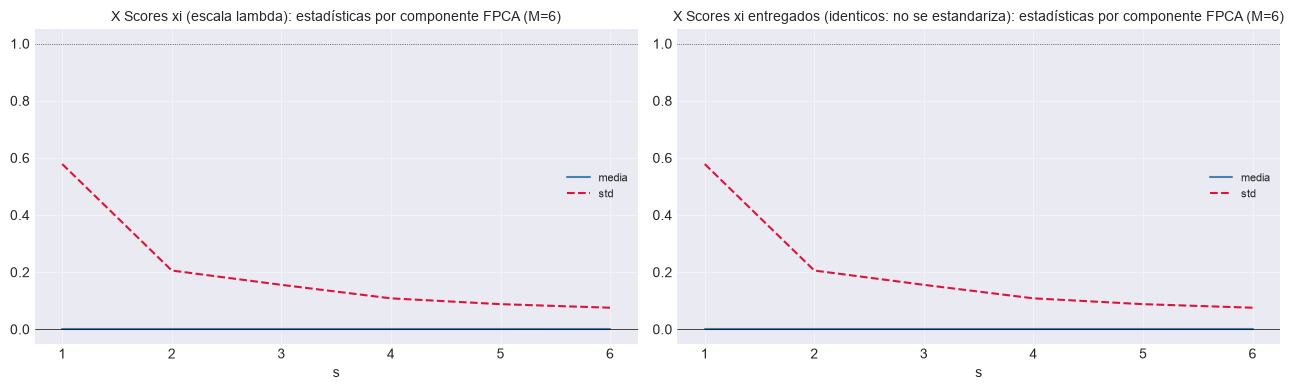

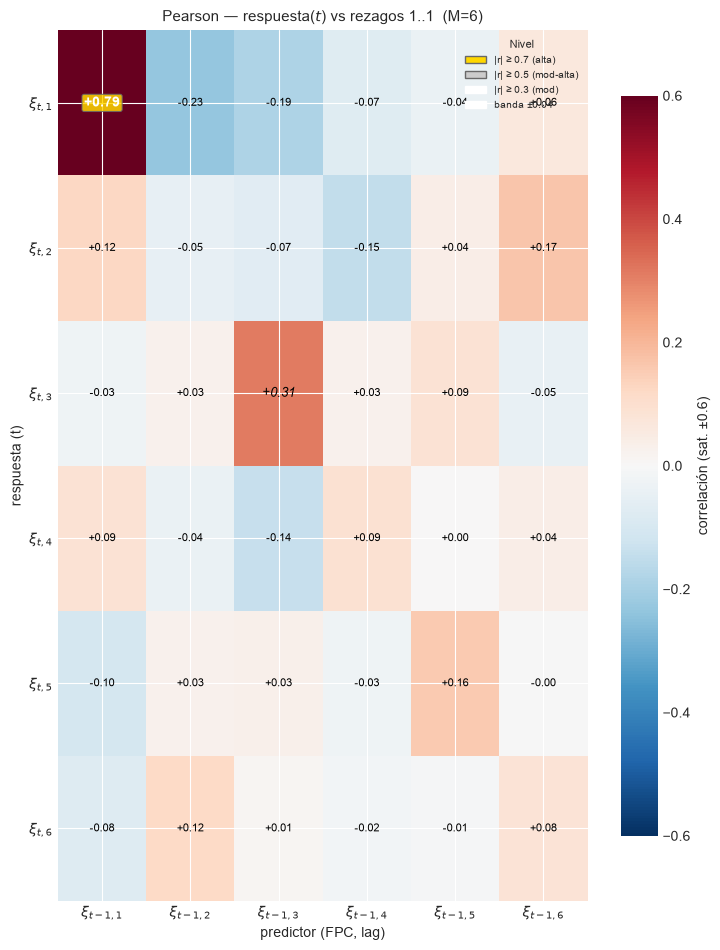

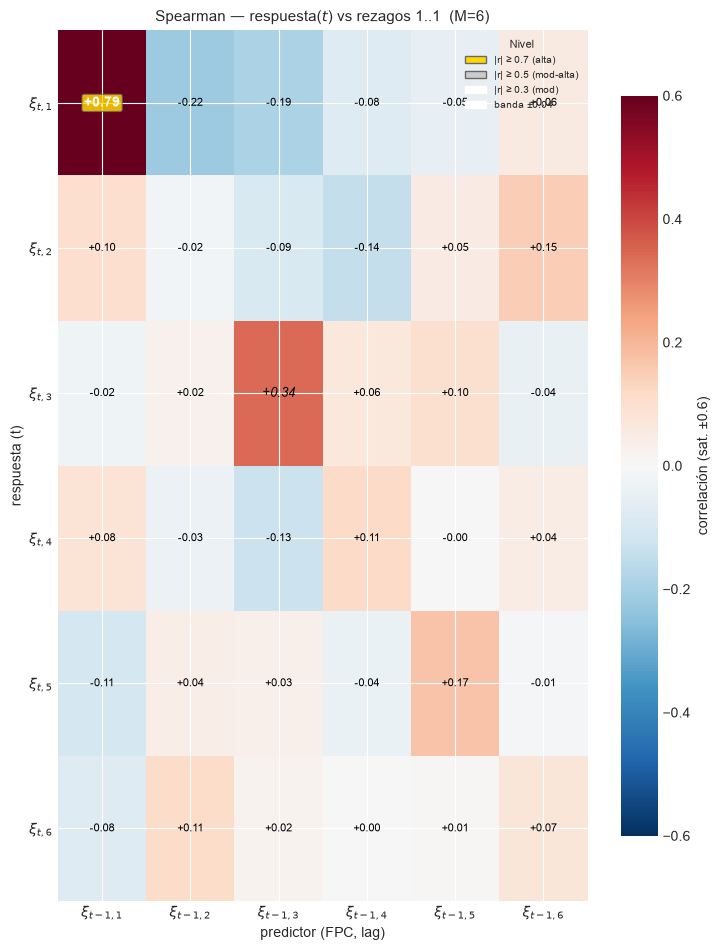

componentes : 6 -> índices [0, 1, 2, 3, 4, 5]
N_LAGS      : 1   ·   p = 6 covariable(s) por componente (cruzadas)
n_train_eff : 2921   n_test_eff : 1096
cov_por_comp: {0: ['fpc_1_lag1', 'fpc_2_lag1', 'fpc_3_lag1', 'fpc_4_lag1', 'fpc_5_lag1', 'fpc_6_lag1'], 1: ['fpc_1_lag1', 'fpc_2_lag1', 'fpc_3_lag1', 'fpc_4_lag1', 'fpc_5_lag1', 'fpc_6_lag1'], 2: ['fpc_1_lag1', 'fpc_2_lag1', 'fpc_3_lag1', 'fpc_4_lag1', 'fpc_5_lag1', 'fpc_6_lag1'], 3: ['fpc_1_lag1', 'fpc_2_lag1', 'fpc_3_lag1', 'fpc_4_lag1', 'fpc_5_lag1', 'fpc_6_lag1'], 4: ['fpc_1_lag1', 'fpc_2_lag1', 'fpc_3_lag1', 'fpc_4_lag1', 'fpc_5_lag1', 'fpc_6_lag1'], 5: ['fpc_1_lag1', 'fpc_2_lag1', 'fpc_3_lag1', 'fpc_4_lag1', 'fpc_5_lag1', 'fpc_6_lag1']}
[functional] 12 datasets + datasets_manifest.json
  fpc_1: train (2921, 7) · test (1096, 7)
  fpc_2: train (2921, 7) · test (1096, 7)
  fpc_3: train (2921, 7) · test (1096, 7)
  fpc_4: train (2921, 7) · test (1096, 7)
  fpc_5: train (2921, 7) · test (1096, 7)
  fpc_6: train (2921, 7) · test (1096,

,n_test,RMSE_fpc1,RMSE_fpc2,RMSE_fpc3,RMSE_fpc4,RMSE_fpc5,RMSE_fpc6,RMSE_scores_prom,R2_scores_prom,MISE,RMSE_funcional
modelo,,,,,,,,,,,
media_incondicional,1096.0000,0.6236,0.2186,0.1544,0.1147,0.0904,0.0773,0.2132,-0.0322,0.5000,0.7071
persistencia_lag1,1096.0000,0.3863,0.3052,0.1808,0.1540,0.1132,0.1059,0.2076,-0.5220,0.3350,0.5788


contrato_ok = True   (M=6, K=10, T0=2922, n_components=6)
estandarizador ajustado con 2922 filas (T0=2922)
verificación FPCA: todo_ok = True


In [66]:
VARIANTE = "chungEscG"      # solo se registra en hyperparameters.json

# -- [CONFIG] Comunes a TODOS los puntos del barrido -------------------------
# Cruzados: xi_(k,t) se predice con xi_(j,t-l), j = 1..M, l = 1..N_LAGS (p = M x N_LAGS).
N_LAGS_ADMITIDOS = (1,)   # esta corrida: un solo rezago
N_LAGS      = 1
assert N_LAGS in N_LAGS_ADMITIDOS, f"N_LAGS admitido: {N_LAGS_ADMITIDOS} (ver HP_BY_TYPE)."

MCMC_CONFIG = {"nsim": 2500, "burn": 500, "N": VAR_CFG["N"], "M": 50}   # ojo: ese M es G*
N_CHAINS    = 1

HP_GLOBAL = {"atau": 2.0, "btau": 0.5, "ag": 0.5, "bg": 0.5,
             "mumu": 0.0, "taumu": 1.0, "pwj": 0.5}

# atau = 2 (no 0.5 de Chung): con atau <= 1 los atomos vacios toman tau ~ 0 y beta enormes
# que rompen la media predictiva (cadena 2 de fpc_1 en M=10, corrida 28).
# Chung §4.2 llevado a la escala cruda. Si x = sd*z, el prior del paper sobre z
# equivale a taupsij = taupsij_z*sd_x^2 y btau = 0.5*sd_y^2 (se aplican en
# procesar_punto). Inclusion: (apij, bpij) = (1, 5), E[pi] = 0.167, igual para propias y cruzadas.
HP_CHUNG_ESC = {"taupsij_z": float(VAR_CFG["taupsij_z"]), "btau_z": 0.5,
                "ab_por_lag": {l: (1.0, 5.0) for l in range(1, N_LAGS + 1)},
                "ab_cruzado": (1.0, 5.0)}
HP_BY_TYPE = {f"own_lag{l}": {"apij": HP_CHUNG_ESC["ab_por_lag"][l][0],
                              "bpij": HP_CHUNG_ESC["ab_por_lag"][l][1]}
              for l in range(1, N_LAGS + 1)}
# Cruzados: el mismo (1, 5); lo unico que se ajusta a los datos es la escala (sd de train).
HP_BY_TYPE.update({f"cross_lag{l}": {"apij": HP_CHUNG_ESC["ab_cruzado"][0],
                                     "bpij": HP_CHUNG_ESC["ab_cruzado"][1]}
                   for l in range(1, N_LAGS + 1)})
print(f"VARIANTE {VARIANTE!r}: HP_GLOBAL={HP_GLOBAL}")
for _t, _v in HP_BY_TYPE.items():
    print(f"  {_t}: apij={_v['apij']}, bpij={_v['bpij']}  E[pi]={_v['apij'] / (_v['apij'] + _v['bpij']):.3f}")
print(f"N={MCMC_CONFIG['N']}  ·  mupsij=0, taupsij={HP_CHUNG_ESC['taupsij_z']:g}*sd_x^2, "
      "btau=0.5*sd_y^2 (Chung en escala cruda)")
print(f"N_LAGS={N_LAGS}  ·  MCMC_CONFIG={MCMC_CONFIG}  ·  N_CHAINS={N_CHAINS}")
print(f"Draws posteriores por score: "
      f"({MCMC_CONFIG['nsim']} - {MCMC_CONFIG['burn']}) x {N_CHAINS} = "
      f"{(MCMC_CONFIG['nsim'] - MCMC_CONFIG['burn']) * N_CHAINS}")

RESUMEN = [procesar_punto(M) for M in M_FPCA_LIST]


## 5. Resumen del barrido

In [67]:
resumen_df = pd.DataFrame(RESUMEN).set_index("M")
display(resumen_df[["experiment_id", "var_acum", "K", "coincide_regla_95",
                    "n_components", "p_covariables", "contrato_ok"]]
        .style.format({"var_acum": "{:.4%}"})
        .set_caption(f"Barrido en M · {EXPERIMENT_BASE} · "
                     f"K disponible = {resumen_df['K'].iloc[0]}"))

_fallidos = [r for r in RESUMEN if not r["contrato_ok"]]
for r in _fallidos:
    print(f"\n[FALLA] M={r['M']} ({r['experiment_id']}):")
    for p in r["problemas"]:
        print(f"  - {p}")
assert not _fallidos, (
    f"El contrato falla en M = {[r['M'] for r in _fallidos]}. No lanzar MATLAB: "
    f"psbp_fd_iteracion.m leería artefactos inconsistentes.")

print(f"\n{'='*70}\nListo. Siguiente paso, en MATLAB desde esta carpeta:\n"
      f"  >> psbp_fd_iteracion\n"
      f"con M_FPCA_LIST = {list(M_FPCA_LIST)}   (cruzados: se entrena CADA M)\n{'='*70}")

,experiment_id,var_acum,K,coincide_regla_95,n_components,p_covariables,contrato_ok
M,,,,,,,
1,real_pm25_poh_v02_m01,76.6746%,10,False,1,1,True
2,real_pm25_poh_v02_m02,86.3636%,10,False,2,2,True
3,real_pm25_poh_v02_m03,91.9030%,10,False,3,3,True
4,real_pm25_poh_v02_m04,94.5849%,10,False,4,4,True
5,real_pm25_poh_v02_m05,96.3528%,10,True,5,5,True
6,real_pm25_poh_v02_m06,97.6541%,10,False,6,6,True



Listo. Siguiente paso, en MATLAB desde esta carpeta:
  >> psbp_fd_iteracion
con M_FPCA_LIST = [1, 2, 3, 4, 5, 6]   (cruzados: se entrena CADA M)
